In [ ]:
lts_class_limit = 1

In [ ]:
# import os
# import glob
# import pickle
# import numpy as np
# import pandas as pd
# import networkx as nx
# import geopandas as gpd
# import osmnx as ox
# import igraph as ig
# import matplotlib.pyplot as plt
# import gc
# from joblib import Parallel, delayed


# def get_demand_met_fast(G, trips_dict):
#     if not G or not hasattr(G, 'edges'):
#         return 0.0
#     unique_edges = set(tuple(sorted((u, v))) for u, v in G.edges())
#     return sum(trips_dict.get(edge, 0.0) for edge in unique_edges)

# def evaluate_demand_met(graphs_list, trips_dict):
#     return [get_demand_met_fast(G, trips_dict) for G in graphs_list]

# def load_scenario_data(filepath):
#     if not os.path.exists(filepath):
#         return [], []
#     with open(filepath, "rb") as f:
#         data = pickle.load(f)
#     gts = data.get("GTs", [])
#     abstracts = data.get("GT_abstracts", [])
#     gts.insert(0, nx.MultiGraph())
#     abstracts.insert(0, nx.MultiGraph())
#     return gts, abstracts

# # --- BATCHING: Group trips by their starting nodes to slash Dijkstra calls ---
# def parse_and_group_trips_for_igraph(od_demand, exit_points, osmid_to_idx):
#     exit_dict = exit_points.groupby('neighbourhood_id')['osmid'].apply(
#         lambda x: [osmid_to_idx[o] for o in x if o in osmid_to_idx]
#     ).to_dict()

#     grouped_trips = {}
#     total_demand = 0.0
    
#     for _, row in od_demand.iterrows():
#         if pd.isna(row['start_osmid']) or row['total_flow'] <= 0:
#             continue
            
#         s_idxs = exit_dict.get(int(row['start_neighbourhood_id']), []) if row.get('ltn_origin') else []
#         if not s_idxs and row['start_osmid'] in osmid_to_idx:
#             s_idxs = [osmid_to_idx[row['start_osmid']]]
            
#         e_idxs = exit_dict.get(int(row['end_neighbourhood_id']), []) if row.get('ltn_destination') else []
#         if not e_idxs and row['end_osmid'] in osmid_to_idx:
#             e_idxs = [osmid_to_idx[row['end_osmid']]]
            
#         if s_idxs and e_idxs:
#             # Group by a tuple of the start indices
#             s_tuple = tuple(sorted(s_idxs))
#             if s_tuple not in grouped_trips:
#                 grouped_trips[s_tuple] = []
                
#             grouped_trips[s_tuple].append({'ends': e_idxs, 'flow': row['total_flow']})
#             total_demand += row['total_flow']

#     return grouped_trips, total_demand

# def get_bikeablity_lts_2_igraph(results_gts, g_lts2_ig, grouped_trips, osmid_to_idx):
#     bikeable_flows_per_stage = []
    
#     for i, G_routed in enumerate(results_gts):
#         g_current = g_lts2_ig.copy()
        
#         if G_routed is not None and len(G_routed.edges) > 0:
#             new_edges = [(osmid_to_idx[u], osmid_to_idx[v]) for u, v, k, d in G_routed.edges(keys=True, data=True) if u in osmid_to_idx and v in osmid_to_idx]
#             g_current.add_edges(new_edges)
            
#         # O(V+E) - extremely fast component check
#         membership = g_current.connected_components().membership
        
#         stage_total_flow = 0
#         for s_tuple, destinations in grouped_trips.items():
#             start_comps = set(membership[s] for s in s_tuple)
#             for d in destinations:
#                 end_comps = set(membership[e] for e in d['ends'])
#                 if start_comps.intersection(end_comps):
#                     stage_total_flow += d['flow']
                    
#         bikeable_flows_per_stage.append(stage_total_flow)
#     return bikeable_flows_per_stage

# def get_bikeablity_cutoff_igraph(results_gts, g_base_ig, grouped_trips, osmid_to_idx, cutoff=3000):
#     bikeable_flows_per_stage = []
    
#     for i, G_routed in enumerate(results_gts):
#         g_current = g_base_ig.copy()
        
#         if G_routed is not None and len(G_routed.edges) > 0:
#             new_edges, new_weights = [], []
#             for u, v, k, d in G_routed.edges(keys=True, data=True):
#                 if u in osmid_to_idx and v in osmid_to_idx:
#                     new_edges.append((osmid_to_idx[u], osmid_to_idx[v]))
                    
#                     # Safety net: enforce float in case OSMnx hid the length in a list
#                     raw_len = d.get('length', 0)
#                     edge_len = float(raw_len if isinstance(raw_len, list) else raw_len)
#                     new_weights.append(edge_len * 1) 
                    
#             g_current.add_edges(new_edges)
            
#             # THE FIX: Start index is exactly the old edge count
#             start_idx = g_base_ig.ecount() 
#             for idx, w in enumerate(new_weights):
#                 g_current.es[start_idx + idx]['lts_length'] = w
                
#         stage_total_flow = 0
#         for s_tuple, destinations in grouped_trips.items():
#             unique_ends = list(set(e for d in destinations for e in d['ends']))
#             if not unique_ends: continue
            
#             # ONE Dijkstra call per start group instead of per trip
#             dists = np.array(g_current.distances(source=list(s_tuple), target=unique_ends, weights='lts_length'))
#             min_dists = np.min(dists, axis=0)
#             end_dist_map = dict(zip(unique_ends, min_dists))
            
#             for d in destinations:
#                 trip_dist = min([end_dist_map[e] for e in d['ends']])
#                 if trip_dist <= cutoff:
#                     stage_total_flow += d['flow']
                    
#         bikeable_flows_per_stage.append(stage_total_flow)
#     return bikeable_flows_per_stage


# def get_bikeability_continuous_igraph(results_gts, g_base_ig, grouped_trips, osmid_to_idx, total_demand, penalty_cost=20000):
#     if total_demand == 0: return [0.0] * len(results_gts)

#     def compute_stage_costs(graph):
#         stage_savings = 0.0
#         for s_tuple, destinations in grouped_trips.items():
#             unique_ends = list(set(e for d in destinations for e in d['ends']))
#             if not unique_ends: continue
            
#             dists = np.array(graph.distances(source=list(s_tuple), target=unique_ends, weights='lts_length'))
#             min_dists = np.min(dists, axis=0)
#             end_dist_map = dict(zip(unique_ends, min_dists))
            
#             for d in destinations:
#                 trip_dist = min([end_dist_map[e] for e in d['ends']])
#                 final_cost = trip_dist if trip_dist < penalty_cost else penalty_cost
#                 # We calculate raw cost here, subtraction happens later
#                 stage_savings += (final_cost * d['flow'])
#         return stage_savings

#     base_total_cost = compute_stage_costs(g_base_ig)
#     stage_results = []

#     for i, G_routed in enumerate(results_gts):
#         g_current = g_base_ig.copy()
#         if G_routed is not None and len(G_routed.edges) > 0:
#             new_edges, new_weights = [], []
#             for u, v, k, d in G_routed.edges(keys=True, data=True):
#                 if u in osmid_to_idx and v in osmid_to_idx:
#                     new_edges.append((osmid_to_idx[u], osmid_to_idx[v]))
                    
#                     # Safety net: enforce float
#                     raw_len = d.get('length', 0)
#                     edge_len = float(raw_len if isinstance(raw_len, list) else raw_len)
#                     new_weights.append(edge_len * 1)
                    
#             g_current.add_edges(new_edges)
            
#             # THE FIX: Start index is exactly the old edge count
#             start_idx = g_base_ig.ecount()
#             for idx, w in enumerate(new_weights):
#                 g_current.es[start_idx + idx]['lts_length'] = w

#         current_total_cost = compute_stage_costs(g_current)
#         savings = max(0, base_total_cost - current_total_cost)
#         avg_savings = savings / total_demand
#         stage_results.append(avg_savings)

#     return stage_results

# def process_single_random_run(filepath, g_base_ig, g_lts2_ig, grouped_trips, osmid_to_idx, total_demand, trips_dict, sample_rate):
#     """Worker function for Joblib parallelization."""
#     r_gts, r_abs = load_scenario_data(filepath)
#     if not r_gts or not r_abs: return None
    
#     r_strict = get_bikeablity_lts_2_igraph(r_gts, g_lts2_ig, grouped_trips, osmid_to_idx)
#     r_cutoff = get_bikeablity_cutoff_igraph(r_gts, g_base_ig, grouped_trips, osmid_to_idx, cutoff=3000)
#     r_demand = evaluate_demand_met(r_abs, trips_dict)
#     r_cont = get_bikeability_continuous_igraph(r_gts[::sample_rate], g_base_ig, grouped_trips, osmid_to_idx, total_demand)
#     r_lts_cut = get_bikeablity_lts_cutoff_igraph(r_gts, g_lts2_ig, grouped_trips, osmid_to_idx, cutoff=3000)
    
#     return (r_strict, r_cutoff, r_demand, r_cont)

# def plot_metric(stages, scenario_dict, random_lists, title, ylabel, save_path, ymax=None):
#     plt.figure(figsize=(10, 6))
#     for i, r_flows in enumerate(random_lists):
#         # Dropped alpha to 0.05 so the 100 random lines don't block out the main lines
#         plt.plot(stages, r_flows, color='grey', alpha=0.05, linewidth=1.5, label='Random (Individual)' if i == 0 else None)

#     if random_lists is not None and len(random_lists) > 0:
#         plt.plot(stages, np.mean(random_lists, axis=0), color='blue', linestyle='--', linewidth=2.5, label='Random (Mean)')

#     colors = {'Demand': 'red', 'Betweenness': 'orange', 'Demand LTN Priority': 'green', 'Betweenness LTN Priority': 'purple'}
#     linestyles = {'Demand': '--', 'Betweenness': '-', 'Demand LTN Priority': '-.', 'Betweenness LTN Priority': '-'}
    
#     for name, data in scenario_dict.items():
#         # Uses the linestyles dict to dash the Demand line, keeping the rest solid
#         plt.plot(stages[:len(data)], data, color=colors.get(name, 'black'), linestyle=linestyles.get(name, '-'), linewidth=2.5, label=name)

#     # Lock the Y-axis if a maximum is provided
#     if ymax is not None:
#         plt.ylim(0, ymax)

#     plt.title(title, fontsize=14, fontweight='bold')
#     plt.xlabel("Infrastructure Added (Stages)", fontsize=12)
#     plt.ylabel(ylabel, fontsize=12)
#     plt.grid(True, linestyle=':', alpha=0.6)
#     plt.legend(loc='lower right', fontsize=10)
#     plt.tight_layout()
#     plt.savefig(save_path, dpi=300, bbox_inches='tight')
#     plt.close()


# def get_bikeablity_lts_cutoff_igraph(results_gts, g_lts2_ig, grouped_trips, osmid_to_idx, cutoff=3000):
#     bikeable_flows_per_stage = []
    
#     for i, G_routed in enumerate(results_gts):
#         g_current = g_lts2_ig.copy()
        
#         if G_routed is not None and len(G_routed.edges) > 0:
#             new_edges, new_weights = [], []
#             for u, v, k, d in G_routed.edges(keys=True, data=True):
#                 if u in osmid_to_idx and v in osmid_to_idx:
#                     new_edges.append((osmid_to_idx[u], osmid_to_idx[v]))
                    
#                     raw_len = d.get('length', 0)
#                     edge_len = float(raw_len if isinstance(raw_len, list) else raw_len)
#                     new_weights.append(edge_len * 1) # Upgraded to LTS 1
                    
#             g_current.add_edges(new_edges)
            
#             start_idx = g_lts2_ig.ecount() 
#             for idx, w in enumerate(new_weights):
#                 g_current.es[start_idx + idx]['lts_length'] = w
                
#         stage_total_flow = 0
#         for s_tuple, destinations in grouped_trips.items():
#             unique_ends = list(set(e for d in destinations for e in d['ends']))
#             if not unique_ends: continue
            
#             # Dijkstra routing but ONLY on the LTS <= 2 graph
#             dists = np.array(g_current.distances(source=list(s_tuple), target=unique_ends, weights='lts_length'))
#             min_dists = np.min(dists, axis=0)
#             end_dist_map = dict(zip(unique_ends, min_dists))
            
#             for d in destinations:
#                 trip_dist = min([end_dist_map[e] for e in d['ends']])
#                 if trip_dist <= cutoff:
#                     stage_total_flow += d['flow']
                    
#         bikeable_flows_per_stage.append(stage_total_flow)
#     return bikeable_flows_per_stage



# # ==========================================
# # 2. MAIN EXECUTION LOOP
# # ==========================================

# places = ["newcastle", "north_tyneside", "south_tyneside", "sunderland", "gateshead",]
# base_dir = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external"
# debug_dir = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\debugging"
# os.makedirs(debug_dir, exist_ok=True)

# lts_mapping = {
#     "motorway": 4, "motorway_link": 4, "trunk": 4, "trunk_link": 4,
#     "primary": 4, "primary_link": 4, "secondary": 4, "secondary_link": 4,
#     "tertiary": 3, "tertiary_link": 3, "unclassified": 3,
#     "residential": 2, "living_street": 2,
#     "cycleway": 1, "track": 1, "path": 1, "bridleway": 1, "footway": 1, "pedestrian": 1
# }

# STAGE_SAMPLE_RATE = 1  # go at every step

# global_main_strict = { 'Demand': [], 'Betweenness': [], 'Demand LTN Priority': [], 'Betweenness LTN Priority': [] }
# global_main_cutoff = { 'Demand': [], 'Betweenness': [], 'Demand LTN Priority': [], 'Betweenness LTN Priority': [] }
# global_main_demand = { 'Demand': [], 'Betweenness': [], 'Demand LTN Priority': [], 'Betweenness LTN Priority': [] }
# global_main_cont = { 'Demand': [], 'Betweenness': [], 'Demand LTN Priority': [], 'Betweenness LTN Priority': [] }
# global_main_lts_cutoff = { 'Demand': [], 'Betweenness': [], 'Demand LTN Priority': [], 'Betweenness LTN Priority': [] }

# global_random_strict = []
# global_random_cutoff = []
# global_random_demand = []
# global_random_cont = []
# global_random_lts_cutoff = []


# for place in places:
#     print(f"\n{'='*50}\nProcessing Location: {place.upper()}\n{'='*50}")
    
#     results_dir = os.path.join(base_dir, "results", place, "current_ltn_scenario")
#     data_dir = os.path.join(base_dir, "data", place, "current_ltn_scenario")
#     exports_dir = os.path.join(base_dir, "exports_gpkg", place, "current_ltn_scenario")

#     # ---------------------------------------------------------
#     # A. Load & Prepare Spatial Data
#     # ---------------------------------------------------------
#     print("Loading and preparing spatial data...")
#     od_demand = gpd.read_file(os.path.join(data_dir, f"{place}_current_ltn_scenario_greedy_demand_weighted.gpkg"))
#     exit_points = gpd.read_file(os.path.join(exports_dir, f"{place}_exit_points.gpkg"))
#     ltns = gpd.read_file(os.path.join(data_dir, f"scored_neighbourhoods_{place}.gpkg"))
    
#     bikeable_gpkg = os.path.join(data_dir, f"{place}_biketrackcarall.gpkg")
#     G_bikeable_nx = ox.graph_from_gdfs(
#         gpd.read_file(bikeable_gpkg, layer="nodes").set_index("osmid"), 
#         gpd.read_file(bikeable_gpkg, layer="edges").set_index(["u", "v", "key"])
#     )

#     start_points = od_demand['geometry'].apply(lambda line: line.interpolate(0, normalized=True) if line is not None else None)
#     end_points = od_demand['geometry'].apply(lambda line: line.interpolate(1, normalized=True) if line is not None else None)
#     gdf_starts = gpd.GeoDataFrame(geometry=start_points, crs=od_demand.crs)
#     gdf_ends = gpd.GeoDataFrame(geometry=end_points, crs=od_demand.crs)
    
#     if ltns.crs != od_demand.crs: ltns = ltns.to_crs(od_demand.crs)
#     ltns_clean = ltns.drop(columns=['index_left', 'index_right'], errors='ignore').copy()
#     ltns_clean['neighbourhood_id'] = ltns_clean.index

#     starts_joined = gpd.sjoin(gdf_starts, ltns_clean, how='left', predicate='intersects')
#     ends_joined = gpd.sjoin(gdf_ends, ltns_clean, how='left', predicate='intersects')
#     starts_joined = starts_joined[~starts_joined.index.duplicated(keep='first')]
#     ends_joined = ends_joined[~ends_joined.index.duplicated(keep='first')]

#     od_demand['start_neighbourhood_id'] = starts_joined['neighbourhood_id']
#     od_demand['end_neighbourhood_id'] = ends_joined['neighbourhood_id']
#     od_demand['ltn_origin'] = od_demand['start_neighbourhood_id'].notna()
#     od_demand['ltn_destination'] = od_demand['end_neighbourhood_id'].notna()

#     G_base = G_bikeable_nx.copy()
#     _, edges_gdf = ox.graph_to_gdfs(G_base)
#     if edges_gdf.crs != ltns.crs: ltns = ltns.to_crs(edges_gdf.crs)
    
#     edges_gdf = edges_gdf.drop(columns=['index_left', 'index_right'], errors='ignore')
#     ltns = ltns.drop(columns=['index_left', 'index_right'], errors='ignore')
#     edges_in_ltn = gpd.sjoin(edges_gdf, ltns, how='inner', predicate='intersects')
#     ltn_edge_indices = set(edges_in_ltn.index)
#     nx.set_edge_attributes(G_base, {(u, v, k): ((u, v, k) in ltn_edge_indices) for u, v, k in G_base.edges(keys=True)}, 'ltn_flag')

#     for u, v, key, data in G_base.edges(keys=True, data=True):
#         is_ltn = data.get('ltn_flag')
#         lts_class = 1 if (is_ltn is True or str(is_ltn).lower() == 'true') else lts_mapping.get(data.get('highway', ['']) if isinstance(data.get('highway'), list) else data.get('highway'), 4)
#         data['lts_class'] = lts_class
#         data['lts_length'] = data.get('length', 0) * lts_class

#     print("Pre-compiling base graphs into igraph C-backend...")
#     g_base_ig = ig.Graph.from_networkx(G_base.to_undirected())
#     osmid_to_idx = {osmid: idx for idx, osmid in enumerate(g_base_ig.vs['_nx_name'])}
    
#     g_lts2_ig = g_base_ig.copy()
#     edges_to_delete = [e.index for e in g_lts2_ig.es if e['lts_class'] > lts_class_limit]
#     g_lts2_ig.delete_edges(edges_to_delete)

#     print("Pre-parsing & Batching Trips...")
#     grouped_trips, total_demand = parse_and_group_trips_for_igraph(od_demand, exit_points, osmid_to_idx)
    
#     mydemand = od_demand.copy()
#     mydemand["edge_id"] = mydemand.apply(lambda r: tuple(sorted((r.start_osmid, r.end_osmid))), axis=1)
#     trips_dict = dict(zip(mydemand["edge_id"], mydemand["total_flow"]))

#     # ---------------------------------------------------------
#     # B. Main Scenarios Evaluation
#     # ---------------------------------------------------------
#     print("Evaluating main scenarios...")
#     paths = {
#         'Demand': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_demand_weighted_current_ltn_scenario.pickle"),
#         'Betweenness': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_betweenness_weighted_current_ltn_scenario.pickle"),
#         'Demand LTN Priority': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_demand_ltn_priority_weighted_current_ltn_scenario.pickle"),
#         'Betweenness LTN Priority': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_betweenness_ltn_priority_weighted_current_ltn_scenario.pickle")
#     }

#     results_strict, results_cutoff, results_demand_met, results_continuous, results_lts_cutoff = {}, {}, {}, {}, {}
#     stages, stages_sampled = None, None

#     for name, path in paths.items():
#         gts, abstracts = load_scenario_data(path)
#         if stages is None and gts:
#             stages = list(range(len(gts)))
#             stages_sampled = stages[::STAGE_SAMPLE_RATE]

#         if gts and abstracts:
#             results_strict[name] = get_bikeablity_lts_2_igraph(gts, g_lts2_ig, grouped_trips, osmid_to_idx)
#             results_cutoff[name] = get_bikeablity_cutoff_igraph(gts, g_base_ig, grouped_trips, osmid_to_idx, cutoff=3000)
#             results_demand_met[name] = evaluate_demand_met(abstracts, trips_dict)
#             results_continuous[name] = get_bikeability_continuous_igraph(gts[::STAGE_SAMPLE_RATE], g_base_ig, grouped_trips, osmid_to_idx, total_demand)
#             results_lts_cutoff[name] = get_bikeablity_lts_cutoff_igraph(gts, g_lts2_ig, grouped_trips, osmid_to_idx, cutoff=3000)
#         del gts, abstracts
#         gc.collect()

#     # ---------------------------------------------------------
#     # C. Random Runs Evaluation (PARALLEL PROCESSING)
#     # ---------------------------------------------------------
#     random_files = sorted(glob.glob(os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_random_weighted_current_ltn_scenario_run*.pickle")))
#     print(f"Evaluating {len(random_files)} Random Runs in parallel across multiple CPU cores...")
    
#     # n_jobs=4 safely utilizes 4 CPU cores. Increase to 6 or 8 if your computer handles it well!
#     # Set verbose=10 to force joblib to print progress updates for every batch
#     parallel_results = Parallel(n_jobs=4, verbose=10)(
#         delayed(process_single_random_run)(f, g_base_ig, g_lts2_ig, grouped_trips, osmid_to_idx, total_demand, trips_dict, STAGE_SAMPLE_RATE) 
#         for f in random_files
#     )
    
#     # Filter valid results
#     valid_results = [res for res in parallel_results if res is not None]

#     # Unpack correctly
#     random_strict_all = [res[0] for res in valid_results]
#     random_cutoff_all = [res[1] for res in valid_results]
#     random_demand_all = [res[2] for res in valid_results]
#     random_continuous_all = [res[3] for res in valid_results]
#     random_lts_cutoff_all = [res[4] for res in valid_results]
#     # ---------------------------------------------------------
#     # D. Generate Output Plots
#     # ---------------------------------------------------------
#     print(f"Generating line plots for {place}...")
    
#     # Calculate a locked Y-axis maximum for Strict and Demand Met ONLY
#     all_flow_values = (
#         [val for lst in results_strict.values() for val in lst] + [val for lst in random_strict_all for val in lst] +
#         [val for lst in results_demand_met.values() for val in lst] + [val for lst in random_demand_all for val in lst]
#     )
#     flow_ymax = max(all_flow_values) * 1.05 if all_flow_values else None

#     # Pass ymax to Strict and Demand Met. Let Cutoff and Continuous auto-scale.
#     plot_metric(stages, results_strict, random_strict_all, f"{place.title()} - Strict LTS {lts_class_limit}", "Bikeable Trips", os.path.join(debug_dir, f"{place}_bikeability_strict.png"), ymax=flow_ymax)
#     plot_metric(stages, results_cutoff, random_cutoff_all, f"{place.title()} - 3000m Perceived Distance Cutoff", "Bikeable Trips", os.path.join(debug_dir, f"{place}_bikeability_cutoff.png")) 
#     plot_metric(stages, results_demand_met, random_demand_all, f"{place.title()} - Demand Met", "Bikeable Trips", os.path.join(debug_dir, f"{place}_demand_met.png"), ymax=flow_ymax)
#     plot_metric(stages_sampled, results_continuous, random_continuous_all, f"{place.title()} - User Benefit", "Avg Savings of Perceived Distance (m)", os.path.join(debug_dir, f"{place}_bikeability_continuous.png"))
#     plot_metric(stages_sampled, results_lts_cutoff, random_lts_cutoff_all, f"{place.title()} - LTS Cutoff {lts_class_limit}", "Bikeable Trips", os.path.join(debug_dir, f"{place}_bikeability_lts_cutoff.png"))

    
#     place_data_path = os.path.join(debug_dir, f"{place}_data.pickle")
#     with open(place_data_path, "wb") as f:
#         pickle.dump({
#             "stages": stages,
#             "stages_sampled": stages_sampled,
#             "results_strict": results_strict,
#             "results_cutoff": results_cutoff,
#             "results_demand_met": results_demand_met,
#             "results_continuous": results_continuous,
#             "random_strict_all": random_strict_all,
#             "random_cutoff_all": random_cutoff_all,
#             "random_demand_all": random_demand_all,
#             "random_continuous_all": random_continuous_all,
#             "random_lts_cutoff_all": random_lts_cutoff_all
#         }, f)
#     print(f"💾 {place.title()} data securely saved to: {place_data_path}")

#     for name in results_strict.keys():
#         global_main_strict[name].append(results_strict[name])
#         global_main_cutoff[name].append(results_cutoff[name])
#         global_main_demand[name].append(results_demand_met[name])
#         global_main_cont[name].append(results_continuous[name])
#         global_main_lts_cutoff[name].append(results_lts_cutoff[name])

#     global_random_strict.append(random_strict_all)
#     global_random_cutoff.append(random_cutoff_all)
#     global_random_demand.append(random_demand_all)
#     global_random_cont.append(random_continuous_all)
#     global_random_lts_cutoff.append(random_lts_cutoff_all)


#     del G_base, G_bikeable_nx, g_base_ig, g_lts2_ig
#     gc.collect()

# print("\nAll locations processed successfully.")


# print("\n" + "="*50)
# print("ALL LOCATIONS PROCESSED. GENERATING OVERALL REGIONAL PLOTS...")
# print("="*50)

# # 1. Direct averaging for the Main Scenarios
# final_main_strict = {name: np.mean(global_main_strict[name], axis=0) for name in global_main_strict}
# final_main_cutoff = {name: np.mean(global_main_cutoff[name], axis=0) for name in global_main_cutoff}
# final_main_demand = {name: np.mean(global_main_demand[name], axis=0) for name in global_main_demand}
# final_main_cont = {name: np.mean(global_main_cont[name], axis=0) for name in global_main_cont}
# final_main_lts_cutoff = {name: np.mean(global_main_lts_cutoff[name], axis=0) for name in global_main_lts_cutoff}
# # 2. Direct averaging for the 100 Random Runs across all 5 cities
# final_random_strict = np.mean(global_random_strict, axis=0)
# final_random_cutoff = np.mean(global_random_cutoff, axis=0)
# final_random_demand = np.mean(global_random_demand, axis=0)
# final_random_cont = np.mean(global_random_cont, axis=0)
# final_random_lts_cutoff = np.mean(global_random_lts_cutoff, axis=0)

# # Calculate a locked Y-axis maximum for the overall Master Strict and Demand Met metrics ONLY
# all_master_flows = (
#     [val for lst in final_main_strict.values() for val in lst] + [val for val in final_random_strict] +
#     [val for lst in final_main_demand.values() for val in lst] + [val for val in final_random_demand]
# )
# master_ymax = max(all_master_flows) * 1.05 if all_master_flows else None

# # Plot the Overall Master Plots WITHOUT the brackets around final_random!
# plot_metric(stages, final_main_strict, final_random_strict, f"Overall Region Results  - Strict LTS {lts_class_limit}", "Average Connected Flow", os.path.join(debug_dir, "OVERALL_bikeability_strict.png"), ymax=master_ymax)
# plot_metric(stages, final_main_cutoff, final_random_cutoff, "Overall Region Results  - 3000m Perceived Distance Cutoff", "Average Connected Flow", os.path.join(debug_dir, "OVERALL_bikeability_cutoff.png")) 
# plot_metric(stages, final_main_demand, final_random_demand, "Overall Region Results  - Demand Met", "Average Cycling Demand Met", os.path.join(debug_dir, "OVERALL_demand_met.png"), ymax=master_ymax)
# plot_metric(stages_sampled, final_main_cont, final_random_cont, "Overall Region Results - User Benefit", "Average Savings of Perceived Distance (m)", os.path.join(debug_dir, "OVERALL_bikeability_continuous.png"))
# plot_metric(stages_sampled, final_main_lts_cutoff, final_random_lts_cutoff, f"Overall Region Results - LTS Cutoff {lts_class_limit}", "Bikeable Trips", os.path.join(debug_dir, "OVERALL_bikeability_lts_cutoff.png"))
# print("\n🎉 MASTER PLOTS GENERATED SUCCESSFULLY!")

# # --- SAVE EVERYTHING TO PICKLE ---
# master_data_path = os.path.join(debug_dir, "OVERALL_REGION_DATA.pickle")
# with open(master_data_path, "wb") as f:
#     pickle.dump({
#         "stages": stages,
#         "stages_sampled": stages_sampled,
#         "final_main_strict": final_main_strict,
#         "final_main_cutoff": final_main_cutoff,
#         "final_main_demand": final_main_demand,
#         "final_main_cont": final_main_cont,
#         "final_random_strict": final_random_strict,
#         "final_random_cutoff": final_random_cutoff,
#         "final_random_demand": final_random_demand,
#         "final_random_cont": final_random_cont
#     }, f)
# print(f"💾 All regional data securely saved to: {master_data_path}")


# # ==========================================
# # CUMULATIVE BENEFIT (AREA UNDER THE CURVE)
# # ==========================================

# # ==========================================
# # CUMULATIVE BENEFIT (AREA UNDER THE CURVE)
# # ==========================================
# auc_output_path = os.path.join(debug_dir, "OVERALL_REGION_AUC_LEADERBOARD.txt")

# def generate_auc_report(metric_name, x_axis, main_dict, random_matrix, is_continuous=False):
#     lines = []
#     lines.append(f"\n--- {metric_name} ---")
    
#     # Calculate AUC for the 4 main scenarios
#     scores = {}
#     for name, y_data in main_dict.items():
#         # np.trapz calculates the exact area under the line
#         scores[name] = np.trapz(y_data, x=x_axis)
        
#     # Calculate AUC for the Random mean line
#     random_mean_line = np.mean(random_matrix, axis=0)
#     scores['Random (Mean)'] = np.trapz(random_mean_line, x=x_axis)
    
#     # Set the baseline (Using 'Demand' as the standard benchmark)
#     baseline_name = 'Demand' if 'Demand' in scores else list(scores.keys())
#     baseline_auc = scores[baseline_name]
    
#     # Sort from highest AUC to lowest (item ensures we sort by the score, not the name)
#     sorted_scores = sorted(scores.items(), key=lambda item: item, reverse=True)
    
#     # Format the leaderboard
#     for rank, (name, auc) in enumerate(sorted_scores, 1):
#         # Calculate percentage difference from the baseline
#         if name == baseline_name:
#             pct_str = " (BASELINE)"
#         else:
#             if baseline_auc != 0:
#                 pct_diff = ((auc - baseline_auc) / baseline_auc) * 100
#                 word = "Better" if pct_diff > 0 else "Worse"
#                 pct_str = f" | {abs(pct_diff):.2f}% {word} than {baseline_name}"
#             else:
#                 pct_str = ""

#         if is_continuous:
#             lines.append(f"{rank}. {name:<26} | AUC: {auc:,.1f} (Meter-Stages){pct_str}")
#         else:
#             lines.append(f"{rank}. {name:<26} | AUC: {auc:,.0f} (Trip-Stages){pct_str}")
            
#     return "\n".join(lines)

# # Build the final string (Using 'stages' and 'stages_sampled' from your main loop)
# report_content = []
# report_content.append("="*85)
# report_content.append("🏆 REGIONAL LEADERBOARD: AREA UNDER THE CURVE (AUC) 🏆")
# report_content.append("Higher AUC = Faster network connectivity & earlier user benefit")
# report_content.append("="*85)

# report_content.append(generate_auc_report(f"Strict LTS {lts_class_limit}", stages, final_main_strict, final_random_strict))
# report_content.append(generate_auc_report("3000m Perceived Distance Cutoff", stages, final_main_cutoff, final_random_cutoff))
# report_content.append(generate_auc_report("Demand Met", stages, final_main_demand, final_random_demand))
# report_content.append(generate_auc_report("User Benefit (Continuous)", stages_sampled, final_main_cont, final_random_cont, is_continuous=True))
# report_content.append(generate_auc_report(f"LTS Cutoff {lts_class_limit}", stages_sampled, final_main_lts_cutoff, final_random_lts_cutoff))
# report_content.append("\n" + "="*85)

# # 1. Print it to the console so you can see it instantly
# final_text = "\n".join(report_content)
# print(final_text)

# # 2. Save it permanently to a text file
# with open(auc_output_path, "w", encoding="utf-8") as f:
#     f.write(final_text)

# print(f"\n📄 Leaderboard successfully saved to: {auc_output_path}")

In [ ]:
import os
import glob
import pickle
import numpy as np
import pandas as pd
import networkx as nx
import geopandas as gpd
import osmnx as ox
import igraph as ig
import matplotlib.pyplot as plt
import gc
from joblib import Parallel, delayed


def get_demand_met_fast(G, trips_dict):
    if not G or not hasattr(G, 'edges'):
        return 0.0
    unique_edges = set(tuple(sorted((u, v))) for u, v in G.edges())
    return sum(trips_dict.get(edge, 0.0) for edge in unique_edges)

def evaluate_demand_met(graphs_list, trips_dict):
    return [get_demand_met_fast(G, trips_dict) for G in graphs_list]

def load_scenario_data(filepath):
    if not os.path.exists(filepath):
        return [], []
    with open(filepath, "rb") as f:
        data = pickle.load(f)
    gts = data.get("GTs", [])
    abstracts = data.get("GT_abstracts", [])
    gts.insert(0, nx.MultiGraph())
    abstracts.insert(0, nx.MultiGraph())
    return gts, abstracts

# --- BATCHING: Group trips by their starting nodes to slash Dijkstra calls ---
def parse_and_group_trips_for_igraph(od_demand, exit_points, osmid_to_idx):
    exit_dict = exit_points.groupby('neighbourhood_id')['osmid'].apply(
        lambda x: [osmid_to_idx[o] for o in x if o in osmid_to_idx]
    ).to_dict()

    grouped_trips = {}
    total_demand = 0.0
    
    for _, row in od_demand.iterrows():
        if pd.isna(row['start_osmid']) or row['total_flow'] <= 0:
            continue
            
        s_idxs = exit_dict.get(int(row['start_neighbourhood_id']), []) if row.get('ltn_origin') else []
        if not s_idxs and row['start_osmid'] in osmid_to_idx:
            s_idxs = [osmid_to_idx[row['start_osmid']]]
            
        e_idxs = exit_dict.get(int(row['end_neighbourhood_id']), []) if row.get('ltn_destination') else []
        if not e_idxs and row['end_osmid'] in osmid_to_idx:
            e_idxs = [osmid_to_idx[row['end_osmid']]]
            
        if s_idxs and e_idxs:
            # Group by a tuple of the start indices
            s_tuple = tuple(sorted(s_idxs))
            if s_tuple not in grouped_trips:
                grouped_trips[s_tuple] = []
                
            grouped_trips[s_tuple].append({'ends': e_idxs, 'flow': row['total_flow']})
            total_demand += row['total_flow']

    return grouped_trips, total_demand

def get_bikeablity_lts_2_igraph(results_gts, g_lts2_ig, grouped_trips, osmid_to_idx):
    bikeable_flows_per_stage = []
    
    for i, G_routed in enumerate(results_gts):
        g_current = g_lts2_ig.copy()
        
        if G_routed is not None and len(G_routed.edges) > 0:
            new_edges = [(osmid_to_idx[u], osmid_to_idx[v]) for u, v, k, d in G_routed.edges(keys=True, data=True) if u in osmid_to_idx and v in osmid_to_idx]
            g_current.add_edges(new_edges)
            
        # O(V+E) - extremely fast component check
        membership = g_current.connected_components().membership
        
        stage_total_flow = 0
        for s_tuple, destinations in grouped_trips.items():
            start_comps = set(membership[s] for s in s_tuple)
            for d in destinations:
                end_comps = set(membership[e] for e in d['ends'])
                if start_comps.intersection(end_comps):
                    stage_total_flow += d['flow']
                    
        bikeable_flows_per_stage.append(stage_total_flow)
    return bikeable_flows_per_stage

def get_bikeablity_cutoff_igraph(results_gts, g_base_ig, grouped_trips, osmid_to_idx, cutoff=3000):
    bikeable_flows_per_stage = []
    
    for i, G_routed in enumerate(results_gts):
        g_current = g_base_ig.copy()
        
        if G_routed is not None and len(G_routed.edges) > 0:
            new_edges, new_weights = [], []
            for u, v, k, d in G_routed.edges(keys=True, data=True):
                if u in osmid_to_idx and v in osmid_to_idx:
                    new_edges.append((osmid_to_idx[u], osmid_to_idx[v]))
                    
                    # Safety net: enforce float in case OSMnx hid the length in a list
                    raw_len = d.get('length', 0)
                    edge_len = float(raw_len if isinstance(raw_len, list) else raw_len)
                    new_weights.append(edge_len * 1) 
                    
            g_current.add_edges(new_edges)
            
            # THE FIX: Start index is exactly the old edge count
            start_idx = g_base_ig.ecount() 
            for idx, w in enumerate(new_weights):
                g_current.es[start_idx + idx]['lts_length'] = w
                
        stage_total_flow = 0
        for s_tuple, destinations in grouped_trips.items():
            unique_ends = list(set(e for d in destinations for e in d['ends']))
            if not unique_ends: continue
            
            # ONE Dijkstra call per start group instead of per trip
            dists = np.array(g_current.distances(source=list(s_tuple), target=unique_ends, weights='lts_length'))
            min_dists = np.min(dists, axis=0)
            end_dist_map = dict(zip(unique_ends, min_dists))
            
            for d in destinations:
                trip_dist = min([end_dist_map[e] for e in d['ends']])
                if trip_dist <= cutoff:
                    stage_total_flow += d['flow']
                    
        bikeable_flows_per_stage.append(stage_total_flow)
    return bikeable_flows_per_stage


def get_bikeability_continuous_igraph(results_gts, g_base_ig, grouped_trips, osmid_to_idx, total_demand, penalty_cost=20000):
    if total_demand == 0: return [0.0] * len(results_gts)

    def compute_stage_costs(graph):
        stage_savings = 0.0
        for s_tuple, destinations in grouped_trips.items():
            unique_ends = list(set(e for d in destinations for e in d['ends']))
            if not unique_ends: continue
            
            dists = np.array(graph.distances(source=list(s_tuple), target=unique_ends, weights='lts_length'))
            min_dists = np.min(dists, axis=0)
            end_dist_map = dict(zip(unique_ends, min_dists))
            
            for d in destinations:
                trip_dist = min([end_dist_map[e] for e in d['ends']])
                final_cost = trip_dist if trip_dist < penalty_cost else penalty_cost
                # We calculate raw cost here, subtraction happens later
                stage_savings += (final_cost * d['flow'])
        return stage_savings

    base_total_cost = compute_stage_costs(g_base_ig)
    stage_results = []

    for i, G_routed in enumerate(results_gts):
        g_current = g_base_ig.copy()
        if G_routed is not None and len(G_routed.edges) > 0:
            new_edges, new_weights = [], []
            for u, v, k, d in G_routed.edges(keys=True, data=True):
                if u in osmid_to_idx and v in osmid_to_idx:
                    new_edges.append((osmid_to_idx[u], osmid_to_idx[v]))
                    
                    # Safety net: enforce float
                    raw_len = d.get('length', 0)
                    edge_len = float(raw_len if isinstance(raw_len, list) else raw_len)
                    new_weights.append(edge_len * 1)
                    
            g_current.add_edges(new_edges)
            
            # THE FIX: Start index is exactly the old edge count
            start_idx = g_base_ig.ecount()
            for idx, w in enumerate(new_weights):
                g_current.es[start_idx + idx]['lts_length'] = w

        current_total_cost = compute_stage_costs(g_current)
        savings = max(0, base_total_cost - current_total_cost)
        avg_savings = savings / total_demand
        stage_results.append(avg_savings)

    return stage_results

def get_bikeablity_lts_cutoff_igraph(results_gts, g_lts2_ig, grouped_trips, osmid_to_idx, cutoff=3000):
    bikeable_flows_per_stage = []
    
    for i, G_routed in enumerate(results_gts):
        g_current = g_lts2_ig.copy()
        
        if G_routed is not None and len(G_routed.edges) > 0:
            new_edges, new_weights = [], []
            for u, v, k, d in G_routed.edges(keys=True, data=True):
                if u in osmid_to_idx and v in osmid_to_idx:
                    new_edges.append((osmid_to_idx[u], osmid_to_idx[v]))
                    
                    raw_len = d.get('length', 0)
                    edge_len = float(raw_len if isinstance(raw_len, list) else raw_len)
                    new_weights.append(edge_len * 1) # Upgraded to LTS 1
                    
            g_current.add_edges(new_edges)
            
            start_idx = g_lts2_ig.ecount() 
            for idx, w in enumerate(new_weights):
                g_current.es[start_idx + idx]['lts_length'] = w
                
        stage_total_flow = 0
        for s_tuple, destinations in grouped_trips.items():
            unique_ends = list(set(e for d in destinations for e in d['ends']))
            if not unique_ends: continue
            
            # Dijkstra routing but ONLY on the LTS <= 2 graph
            dists = np.array(g_current.distances(source=list(s_tuple), target=unique_ends, weights='lts_length'))
            min_dists = np.min(dists, axis=0)
            end_dist_map = dict(zip(unique_ends, min_dists))
            
            for d in destinations:
                trip_dist = min([end_dist_map[e] for e in d['ends']])
                if trip_dist <= cutoff:
                    stage_total_flow += d['flow']
                    
        bikeable_flows_per_stage.append(stage_total_flow)
    return bikeable_flows_per_stage


def process_single_random_run(filepath, g_base_ig, g_lts2_ig, grouped_trips, osmid_to_idx, total_demand, trips_dict, sample_rate):
    """Worker function for Joblib parallelization."""
    r_gts, r_abs = load_scenario_data(filepath)
    if not r_gts or not r_abs: return None
    
    r_strict = get_bikeablity_lts_2_igraph(r_gts, g_lts2_ig, grouped_trips, osmid_to_idx)
    r_cutoff = get_bikeablity_cutoff_igraph(r_gts, g_base_ig, grouped_trips, osmid_to_idx, cutoff=3000)
    r_demand = evaluate_demand_met(r_abs, trips_dict)
    r_cont = get_bikeability_continuous_igraph(r_gts[::sample_rate], g_base_ig, grouped_trips, osmid_to_idx, total_demand)
    r_lts_cut = get_bikeablity_lts_cutoff_igraph(r_gts, g_lts2_ig, grouped_trips, osmid_to_idx, cutoff=3000)
    
    return (r_strict, r_cutoff, r_demand, r_cont, r_lts_cut)

def plot_metric(stages, scenario_dict, random_lists, title, ylabel, save_path, ymax=None):
    plt.figure(figsize=(10, 6))
    for i, r_flows in enumerate(random_lists):
        # Dropped alpha to 0.05 so the 100 random lines don't block out the main lines
        plt.plot(stages, r_flows, color='grey', alpha=0.05, linewidth=1.5, label='Random (Individual)' if i == 0 else None)

    if random_lists is not None and len(random_lists) > 0:
        plt.plot(stages, np.mean(random_lists, axis=0), color='blue', linestyle='--', linewidth=2.5, label='Random (Mean)')

    colors = {'Demand': 'red', 'Betweenness': 'orange', 'Demand LTN Priority': 'green', 'Betweenness LTN Priority': 'purple'}
    linestyles = {'Demand': '--', 'Betweenness': '-', 'Demand LTN Priority': '-.', 'Betweenness LTN Priority': '-'}
    
    for name, data in scenario_dict.items():
        # Uses the linestyles dict to dash the Demand line, keeping the rest solid
        plt.plot(stages[:len(data)], data, color=colors.get(name, 'black'), linestyle=linestyles.get(name, '-'), linewidth=2.5, label=name)

    # Lock the Y-axis if a maximum is provided
    if ymax is not None:
        plt.ylim(0, ymax)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Infrastructure Added (Stages)", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower right', fontsize=10)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

# ==========================================
# 2. MAIN EXECUTION LOOP
# ==========================================

places = ["newcastle", "north_tyneside", "south_tyneside", "sunderland", "gateshead"]
base_dir = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external"
debug_dir = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\debugging"
os.makedirs(debug_dir, exist_ok=True)

lts_mapping = {
    "motorway": 4, "motorway_link": 4, "trunk": 4, "trunk_link": 4,
    "primary": 4, "primary_link": 4, "secondary": 4, "secondary_link": 4,
    "tertiary": 3, "tertiary_link": 3, "unclassified": 3,
    "residential": 2, "living_street": 2,
    "cycleway": 1, "track": 1, "path": 1, "bridleway": 1, "footway": 1, "pedestrian": 1
}

STAGE_SAMPLE_RATE = 1  # go at every step

global_main_strict = { 'Demand': [], 'Betweenness': [], 'Demand LTN Priority': [], 'Betweenness LTN Priority': [] }
global_main_cutoff = { 'Demand': [], 'Betweenness': [], 'Demand LTN Priority': [], 'Betweenness LTN Priority': [] }
global_main_demand = { 'Demand': [], 'Betweenness': [], 'Demand LTN Priority': [], 'Betweenness LTN Priority': [] }
global_main_cont = { 'Demand': [], 'Betweenness': [], 'Demand LTN Priority': [], 'Betweenness LTN Priority': [] }
global_main_lts_cutoff = { 'Demand': [], 'Betweenness': [], 'Demand LTN Priority': [], 'Betweenness LTN Priority': [] }

global_random_strict = []
global_random_cutoff = []
global_random_demand = []
global_random_cont = []
global_random_lts_cutoff = []

for place in places:
    print(f"\n{'='*50}\nProcessing Location: {place.upper()}\n{'='*50}")
    
    results_dir = os.path.join(base_dir, "results", place, "current_ltn_scenario")
    data_dir = os.path.join(base_dir, "data", place, "current_ltn_scenario")
    exports_dir = os.path.join(base_dir, "exports_gpkg", place, "current_ltn_scenario")

    # ---------------------------------------------------------
    # A. Load & Prepare Spatial Data
    # ---------------------------------------------------------
    print("Loading and preparing spatial data...")
    od_demand = gpd.read_file(os.path.join(data_dir, f"{place}_current_ltn_scenario_greedy_demand_weighted.gpkg"))
    exit_points = gpd.read_file(os.path.join(exports_dir, f"{place}_exit_points.gpkg"))
    ltns = gpd.read_file(os.path.join(data_dir, f"scored_neighbourhoods_{place}.gpkg"))
    
    bikeable_gpkg = os.path.join(data_dir, f"{place}_biketrackcarall.gpkg")
    G_bikeable_nx = ox.graph_from_gdfs(
        gpd.read_file(bikeable_gpkg, layer="nodes").set_index("osmid"), 
        gpd.read_file(bikeable_gpkg, layer="edges").set_index(["u", "v", "key"])
    )

    start_points = od_demand['geometry'].apply(lambda line: line.interpolate(0, normalized=True) if line is not None else None)
    end_points = od_demand['geometry'].apply(lambda line: line.interpolate(1, normalized=True) if line is not None else None)
    gdf_starts = gpd.GeoDataFrame(geometry=start_points, crs=od_demand.crs)
    gdf_ends = gpd.GeoDataFrame(geometry=end_points, crs=od_demand.crs)
    
    if ltns.crs != od_demand.crs: ltns = ltns.to_crs(od_demand.crs)
    ltns_clean = ltns.drop(columns=['index_left', 'index_right'], errors='ignore').copy()
    ltns_clean['neighbourhood_id'] = ltns_clean.index

    starts_joined = gpd.sjoin(gdf_starts, ltns_clean, how='left', predicate='intersects')
    ends_joined = gpd.sjoin(gdf_ends, ltns_clean, how='left', predicate='intersects')
    starts_joined = starts_joined[~starts_joined.index.duplicated(keep='first')]
    ends_joined = ends_joined[~ends_joined.index.duplicated(keep='first')]

    od_demand['start_neighbourhood_id'] = starts_joined['neighbourhood_id']
    od_demand['end_neighbourhood_id'] = ends_joined['neighbourhood_id']
    od_demand['ltn_origin'] = od_demand['start_neighbourhood_id'].notna()
    od_demand['ltn_destination'] = od_demand['end_neighbourhood_id'].notna()

    G_base = G_bikeable_nx.copy()
    _, edges_gdf = ox.graph_to_gdfs(G_base)
    if edges_gdf.crs != ltns.crs: ltns = ltns.to_crs(edges_gdf.crs)
    
    edges_gdf = edges_gdf.drop(columns=['index_left', 'index_right'], errors='ignore')
    ltns = ltns.drop(columns=['index_left', 'index_right'], errors='ignore')
    edges_in_ltn = gpd.sjoin(edges_gdf, ltns, how='inner', predicate='intersects')
    ltn_edge_indices = set(edges_in_ltn.index)
    nx.set_edge_attributes(G_base, {(u, v, k): ((u, v, k) in ltn_edge_indices) for u, v, k in G_base.edges(keys=True)}, 'ltn_flag')

    for u, v, key, data in G_base.edges(keys=True, data=True):
        is_ltn = data.get('ltn_flag')
        raw_hw = data.get('highway')
        hw_type = raw_hw if isinstance(raw_hw, list) else raw_hw
        lts_class = 1 if (is_ltn is True or str(is_ltn).lower() == 'true') else lts_mapping.get(hw_type, 4)
        data['lts_class'] = lts_class
        data['lts_length'] = data.get('length', 0) * lts_class

    print("Pre-compiling base graphs into igraph C-backend...")
    g_base_ig = ig.Graph.from_networkx(G_base.to_undirected())
    osmid_to_idx = {osmid: idx for idx, osmid in enumerate(g_base_ig.vs['_nx_name'])}
    
    g_lts2_ig = g_base_ig.copy()
    edges_to_delete = [e.index for e in g_lts2_ig.es if e['lts_class'] > lts_class_limit]
    g_lts2_ig.delete_edges(edges_to_delete)

    print("Pre-parsing & Batching Trips...")
    grouped_trips, total_demand = parse_and_group_trips_for_igraph(od_demand, exit_points, osmid_to_idx)
    
    mydemand = od_demand.copy()
    mydemand["edge_id"] = mydemand.apply(lambda r: tuple(sorted((r.start_osmid, r.end_osmid))), axis=1)
    trips_dict = dict(zip(mydemand["edge_id"], mydemand["total_flow"]))

    # ---------------------------------------------------------
    # B. Main Scenarios Evaluation
    # ---------------------------------------------------------
    print("Evaluating main scenarios...")
    paths = {
        'Demand': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_demand_weighted_current_ltn_scenario.pickle"),
        'Betweenness': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_betweenness_weighted_current_ltn_scenario.pickle"),
        'Demand LTN Priority': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_demand_ltn_priority_weighted_current_ltn_scenario.pickle"),
        'Betweenness LTN Priority': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_betweenness_ltn_priority_weighted_current_ltn_scenario.pickle")
    }

    results_strict, results_cutoff, results_demand_met, results_continuous, results_lts_cutoff = {}, {}, {}, {}, {}
    stages, stages_sampled = None, None

    for name, path in paths.items():
        gts, abstracts = load_scenario_data(path)
        if stages is None and gts:
            stages = list(range(len(gts)))
            stages_sampled = stages[::STAGE_SAMPLE_RATE]

        if gts and abstracts:
            results_strict[name] = get_bikeablity_lts_2_igraph(gts, g_lts2_ig, grouped_trips, osmid_to_idx)
            results_cutoff[name] = get_bikeablity_cutoff_igraph(gts, g_base_ig, grouped_trips, osmid_to_idx, cutoff=3000)
            results_demand_met[name] = evaluate_demand_met(abstracts, trips_dict)
            results_continuous[name] = get_bikeability_continuous_igraph(gts[::STAGE_SAMPLE_RATE], g_base_ig, grouped_trips, osmid_to_idx, total_demand)
            results_lts_cutoff[name] = get_bikeablity_lts_cutoff_igraph(gts, g_lts2_ig, grouped_trips, osmid_to_idx, cutoff=3000)
        del gts, abstracts
        gc.collect()

    # ---------------------------------------------------------
    # C. Random Runs Evaluation (PARALLEL PROCESSING)
    # ---------------------------------------------------------
    random_files = sorted(glob.glob(os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_random_weighted_current_ltn_scenario_run*.pickle")))
    print(f"Evaluating {len(random_files)} Random Runs in parallel across multiple CPU cores...")
    
    # n_jobs=4 safely utilizes 4 CPU cores. Increase to 6 or 8 if your computer handles it well!
    # Set verbose=10 to force joblib to print progress updates for every batch
    parallel_results = Parallel(n_jobs=4, verbose=10)(
        delayed(process_single_random_run)(f, g_base_ig, g_lts2_ig, grouped_trips, osmid_to_idx, total_demand, trips_dict, STAGE_SAMPLE_RATE) 
        for f in random_files
    )
    
    # Filter valid results
    valid_results = [res for res in parallel_results if res is not None]

    # Unpack correctly
    random_strict_all = [res[0] for res in valid_results]
    random_cutoff_all = [res[1] for res in valid_results]
    random_demand_all = [res[2] for res in valid_results]
    random_continuous_all = [res[3] for res in valid_results]
    random_lts_cutoff_all = [res[4] for res in valid_results]
    
    # ---------------------------------------------------------
    # D. Generate Output Plots
    # ---------------------------------------------------------
    print(f"Generating line plots for {place}...")
    
    # Calculate a locked Y-axis maximum for Strict and Demand Met ONLY
    all_flow_values = (
        [val for lst in results_strict.values() for val in lst] + [val for lst in random_strict_all for val in lst] +
        [val for lst in results_demand_met.values() for val in lst] + [val for lst in random_demand_all for val in lst]
    )
    flow_ymax = max(all_flow_values) * 1.05 if all_flow_values else None

    # Pass ymax to Strict and Demand Met. Let Cutoff and Continuous auto-scale.
    plot_metric(stages, results_strict, random_strict_all, f"{place.title()} - Strict LTS <= 2", "Bikeable Trips", os.path.join(debug_dir, f"{place}_bikeability_strict.png"), ymax=flow_ymax)
    plot_metric(stages, results_cutoff, random_cutoff_all, f"{place.title()} - 3000m Perceived Distance Cutoff", "Bikeable Trips", os.path.join(debug_dir, f"{place}_bikeability_cutoff.png")) 
    plot_metric(stages, results_demand_met, random_demand_all, f"{place.title()} - Demand Met", "Bikeable Trips", os.path.join(debug_dir, f"{place}_demand_met.png"), ymax=flow_ymax)
    plot_metric(stages_sampled, results_continuous, random_continuous_all, f"{place.title()} - User Benefit", "Avg Savings of Perceived Distance (m)", os.path.join(debug_dir, f"{place}_bikeability_continuous.png"))
    plot_metric(stages, results_lts_cutoff, random_lts_cutoff_all, f"{place.title()} - LTS & Cutoff (<=2, 3000m)", "Bikeable Trips", os.path.join(debug_dir, f"{place}_bikeability_lts_cutoff.png"))
    
    place_data_path = os.path.join(debug_dir, f"{place}_data.pickle")
    with open(place_data_path, "wb") as f:
        pickle.dump({
            "stages": stages,
            "stages_sampled": stages_sampled,
            "results_strict": results_strict,
            "results_cutoff": results_cutoff,
            "results_demand_met": results_demand_met,
            "results_continuous": results_continuous,
            "results_lts_cutoff": results_lts_cutoff,
            "random_strict_all": random_strict_all,
            "random_cutoff_all": random_cutoff_all,
            "random_demand_all": random_demand_all,
            "random_continuous_all": random_continuous_all,
            "random_lts_cutoff_all": random_lts_cutoff_all
        }, f)
    print(f"💾 {place.title()} data securely saved to: {place_data_path}")

    for name in results_strict.keys():
        global_main_strict[name].append(results_strict[name])
        global_main_cutoff[name].append(results_cutoff[name])
        global_main_demand[name].append(results_demand_met[name])
        global_main_cont[name].append(results_continuous[name])
        global_main_lts_cutoff[name].append(results_lts_cutoff[name])

    global_random_strict.append(random_strict_all)
    global_random_cutoff.append(random_cutoff_all)
    global_random_demand.append(random_demand_all)
    global_random_cont.append(random_continuous_all)
    global_random_lts_cutoff.append(random_lts_cutoff_all)

    del G_base, G_bikeable_nx, g_base_ig, g_lts2_ig
    gc.collect()

print("\nAll locations processed successfully.")

print("\n" + "="*50)
print("ALL LOCATIONS PROCESSED. GENERATING OVERALL REGIONAL PLOTS...")
print("="*50)

# 1. Direct averaging for the Main Scenarios
final_main_strict = {name: np.mean(global_main_strict[name], axis=0) for name in global_main_strict}
final_main_cutoff = {name: np.mean(global_main_cutoff[name], axis=0) for name in global_main_cutoff}
final_main_demand = {name: np.mean(global_main_demand[name], axis=0) for name in global_main_demand}
final_main_cont = {name: np.mean(global_main_cont[name], axis=0) for name in global_main_cont}
final_main_lts_cutoff = {name: np.mean(global_main_lts_cutoff[name], axis=0) for name in global_main_lts_cutoff}

# 2. Direct averaging for the 100 Random Runs across all 5 cities
final_random_strict = np.mean(global_random_strict, axis=0)
final_random_cutoff = np.mean(global_random_cutoff, axis=0)
final_random_demand = np.mean(global_random_demand, axis=0)
final_random_cont = np.mean(global_random_cont, axis=0)
final_random_lts_cutoff = np.mean(global_random_lts_cutoff, axis=0)

# Calculate a locked Y-axis maximum for the overall Master metrics
# We use .ravel() to ensure 2D arrays (Runs x Stages) become a flat list of numbers
all_master_flows = np.concatenate([
    np.array(list(final_main_strict.values())).ravel(),
    final_random_strict.ravel(),
    np.array(list(final_main_demand.values())).ravel(),
    final_random_demand.ravel()
])

master_ymax = np.max(all_master_flows) * 1.05 if all_master_flows.size > 0 else None

# Plot the Overall Master Plots WITHOUT the brackets around final_random!
plot_metric(stages, final_main_strict, final_random_strict, "Overall Region Results  - Strict LTS <= 2", "Average Connected Flow", os.path.join(debug_dir, "OVERALL_bikeability_strict.png"), ymax=master_ymax)
plot_metric(stages, final_main_cutoff, final_random_cutoff, "Overall Region Results  - 3000m Perceived Distance Cutoff", "Average Connected Flow", os.path.join(debug_dir, "OVERALL_bikeability_cutoff.png")) 
plot_metric(stages, final_main_demand, final_random_demand, "Overall Region Results  - Demand Met", "Average Cycling Demand Met", os.path.join(debug_dir, "OVERALL_demand_met.png"), ymax=master_ymax)
plot_metric(stages_sampled, final_main_cont, final_random_cont, "Overall Region Results - User Benefit", "Average Savings of Perceived Distance (m)", os.path.join(debug_dir, "OVERALL_bikeability_continuous.png"))
plot_metric(stages, final_main_lts_cutoff, final_random_lts_cutoff, "Overall Region Results - LTS & Cutoff (<=2, 3000m)", "Average Connected Flow", os.path.join(debug_dir, "OVERALL_bikeability_lts_cutoff.png"))
print("\n🎉 MASTER PLOTS GENERATED SUCCESSFULLY!")

# --- SAVE EVERYTHING TO PICKLE ---
master_data_path = os.path.join(debug_dir, "OVERALL_REGION_DATA.pickle")
with open(master_data_path, "wb") as f:
    pickle.dump({
        "stages": stages,
        "stages_sampled": stages_sampled,
        "final_main_strict": final_main_strict,
        "final_main_cutoff": final_main_cutoff,
        "final_main_demand": final_main_demand,
        "final_main_cont": final_main_cont,
        "final_main_lts_cutoff": final_main_lts_cutoff,
        "final_random_strict": final_random_strict,
        "final_random_cutoff": final_random_cutoff,
        "final_random_demand": final_random_demand,
        "final_random_cont": final_random_cont,
        "final_random_lts_cutoff": final_random_lts_cutoff
    }, f)
print(f"💾 All regional data securely saved to: {master_data_path}")

# ==========================================
# CUMULATIVE BENEFIT (AREA UNDER THE CURVE)
# ==========================================
auc_output_path = os.path.join(debug_dir, "OVERALL_REGION_AUC_LEADERBOARD.txt")

def generate_auc_report(metric_name, x_axis, main_dict, random_matrix, is_continuous=False):
    lines = []
    lines.append(f"\n--- {metric_name} ---")
    
    # Calculate AUC for the 4 main scenarios
    scores = {}
    for name, y_data in main_dict.items():
        # np.trapz calculates the exact area under the line
        scores[name] = np.trapz(y_data, x=x_axis)
        
    # Calculate AUC for the Random mean line
    random_mean_line = np.mean(random_matrix, axis=0)
    scores['Random (Mean)'] = np.trapz(random_mean_line, x=x_axis)
    
    # Set the baseline (Using 'Random (Mean)' as the standard benchmark)
    baseline_name = 'Random (Mean)'
    baseline_auc = scores[baseline_name]
    
    # Sort from highest AUC to lowest (item ensures we sort by the score, not the name)
    sorted_scores = sorted(scores.items(), key=lambda item: item, reverse=True)
    
    # Format the leaderboard
    for rank, (name, auc) in enumerate(sorted_scores, 1):
        # Calculate percentage difference from the baseline
        if name == baseline_name:
            pct_str = " (BASELINE)"
        else:
            if baseline_auc != 0:
                pct_diff = ((auc - baseline_auc) / baseline_auc) * 100
                word = "Better" if pct_diff > 0 else "Worse"
                pct_str = f" | {abs(pct_diff):.2f}% {word} than {baseline_name}"
            else:
                pct_str = ""

        if is_continuous:
            lines.append(f"{rank}. {name:<26} | AUC: {auc:,.1f} (Meter-Stages){pct_str}")
        else:
            lines.append(f"{rank}. {name:<26} | AUC: {auc:,.0f} (Trip-Stages){pct_str}")
            
    return "\n".join(lines)

# Build the final string (Using 'stages' and 'stages_sampled' from your main loop)
report_content = []
report_content.append("="*85)
report_content.append("🏆 REGIONAL LEADERBOARD: AREA UNDER THE CURVE (AUC) 🏆")
report_content.append("Higher AUC = Faster network connectivity & earlier user benefit")
report_content.append("="*85)

report_content.append(generate_auc_report("Strict LTS <= 2", stages, final_main_strict, final_random_strict))
report_content.append(generate_auc_report("3000m Perceived Distance Cutoff", stages, final_main_cutoff, final_random_cutoff))
report_content.append(generate_auc_report("LTS & Cutoff (<=2, 3000m)", stages, final_main_lts_cutoff, final_random_lts_cutoff))
report_content.append(generate_auc_report("Demand Met", stages, final_main_demand, final_random_demand))
report_content.append(generate_auc_report("User Benefit (Continuous)", stages_sampled, final_main_cont, final_random_cont, is_continuous=True))

report_content.append("\n" + "="*85)

# 1. Print it to the console so you can see it instantly
final_text = "\n".join(report_content)
print(final_text)

# 2. Save it permanently to a text file
with open(auc_output_path, "w", encoding="utf-8") as f:
    f.write(final_text)

print(f"\n📄 Leaderboard successfully saved to: {auc_output_path}")

-------------------------------

# Just run lts cutoff with distance limit

In [ ]:
lts_class_limit = 1  

In [ ]:
import os
import glob
import pickle
import numpy as np
import pandas as pd
import networkx as nx
import geopandas as gpd
import osmnx as ox
import igraph as ig
import matplotlib.pyplot as plt
import gc
from joblib import Parallel, delayed

# ==========================================
# 1. CORE FUNCTIONS FOR LTS CUTOFF ONLY
# ==========================================

def load_scenario_data(filepath):
    if not os.path.exists(filepath):
        return [], []
    with open(filepath, "rb") as f:
        data = pickle.load(f)
    gts = data.get("GTs", [])
    abstracts = data.get("GT_abstracts", [])
    gts.insert(0, nx.MultiGraph())
    abstracts.insert(0, nx.MultiGraph())
    return gts, abstracts

def parse_and_group_trips_for_igraph(od_demand, exit_points, osmid_to_idx):
    exit_dict = exit_points.groupby('neighbourhood_id')['osmid'].apply(
        lambda x: [osmid_to_idx[o] for o in x if o in osmid_to_idx]
    ).to_dict()

    grouped_trips = {}
    
    for _, row in od_demand.iterrows():
        if pd.isna(row['start_osmid']) or row['total_flow'] <= 0:
            continue
            
        s_idxs = exit_dict.get(int(row['start_neighbourhood_id']), []) if row.get('ltn_origin') else []
        if not s_idxs and row['start_osmid'] in osmid_to_idx:
            s_idxs = [osmid_to_idx[row['start_osmid']]]
            
        e_idxs = exit_dict.get(int(row['end_neighbourhood_id']), []) if row.get('ltn_destination') else []
        if not e_idxs and row['end_osmid'] in osmid_to_idx:
            e_idxs = [osmid_to_idx[row['end_osmid']]]
            
        if s_idxs and e_idxs:
            s_tuple = tuple(sorted(s_idxs))
            if s_tuple not in grouped_trips:
                grouped_trips[s_tuple] = []
            grouped_trips[s_tuple].append({'ends': e_idxs, 'flow': row['total_flow']})

    return grouped_trips

def get_bikeablity_lts_cutoff_igraph(results_gts, g_lts2_ig, grouped_trips, osmid_to_idx, cutoff=3000):
    bikeable_flows_per_stage = []
    
    for i, G_routed in enumerate(results_gts):
        g_current = g_lts2_ig.copy()
        
        if G_routed is not None and len(G_routed.edges) > 0:
            new_edges, new_weights = [], []
            for u, v, k, d in G_routed.edges(keys=True, data=True):
                if u in osmid_to_idx and v in osmid_to_idx:
                    new_edges.append((osmid_to_idx[u], osmid_to_idx[v]))
                    
                    raw_len = d.get('length', 0)
                    edge_len = float(raw_len if isinstance(raw_len, list) else raw_len)
                    new_weights.append(edge_len * 1) # Upgraded to LTS 1
                    
            g_current.add_edges(new_edges)
            
            start_idx = g_lts2_ig.ecount() 
            for idx, w in enumerate(new_weights):
                g_current.es[start_idx + idx]['lts_length'] = w
                
        stage_total_flow = 0
        for s_tuple, destinations in grouped_trips.items():
            unique_ends = list(set(e for d in destinations for e in d['ends']))
            if not unique_ends: continue
            
            dists = np.array(g_current.distances(source=list(s_tuple), target=unique_ends, weights='lts_length'))
            min_dists = np.min(dists, axis=0)
            end_dist_map = dict(zip(unique_ends, min_dists))
            
            for d in destinations:
                trip_dist = min([end_dist_map[e] for e in d['ends']])
                if trip_dist <= cutoff:
                    stage_total_flow += d['flow']
                    
        bikeable_flows_per_stage.append(stage_total_flow)
    return bikeable_flows_per_stage

def process_single_random_run(filepath, g_lts2_ig, grouped_trips, osmid_to_idx, cutoff=3000):
    """Worker function for Joblib parallelization - ONLY computes lts_cutoff."""
    r_gts, r_abs = load_scenario_data(filepath)
    if not r_gts or not r_abs: return None
    
    r_lts_cut = get_bikeablity_lts_cutoff_igraph(r_gts, g_lts2_ig, grouped_trips, osmid_to_idx, cutoff=cutoff)
    return r_lts_cut

def plot_metric(stages, scenario_dict, random_lists, title, ylabel, save_path, ymax=None):
    plt.figure(figsize=(10, 6))
    for i, r_flows in enumerate(random_lists):
        plt.plot(stages, r_flows, color='grey', alpha=0.05, linewidth=1.5, label='Random (Individual)' if i == 0 else None)

    if random_lists is not None and len(random_lists) > 0:
        plt.plot(stages, np.mean(random_lists, axis=0), color='blue', linestyle='--', linewidth=2.5, label='Random (Mean)')

    colors = {'Demand': 'red', 'Betweenness': 'orange', 'Demand LTN Priority': 'green', 'Betweenness LTN Priority': 'purple'}
    linestyles = {'Demand': '--', 'Betweenness': '-', 'Demand LTN Priority': '-.', 'Betweenness LTN Priority': '-'}
    
    for name, data in scenario_dict.items():
        plt.plot(stages[:len(data)], data, color=colors.get(name, 'black'), linestyle=linestyles.get(name, '-'), linewidth=2.5, label=name)

    if ymax is not None:
        plt.ylim(0, ymax)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Infrastructure Added (Stages)", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower right', fontsize=10)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

def generate_auc_report(metric_name, x_axis, main_dict, random_matrix):
    lines = []
    lines.append(f"\n--- {metric_name} ---")
    
    scores = {}
    for name, y_data in main_dict.items():
        scores[name] = np.trapz(y_data, x=x_axis)
        
    # Compute random mean AUC separately
    random_mean_line = np.mean(random_matrix, axis=0)
    random_mean_auc = np.trapz(random_mean_line, x=x_axis)

    baseline_name = 'Random (Mean)'
    baseline_auc = random_mean_auc
    
    sorted_scores = sorted(scores.items(), key=lambda item: item, reverse=True)
    
    for rank, (name, auc) in enumerate(sorted_scores, 1):
        if name == baseline_name:
            pct_str = " (BASELINE)"
        else:
            if baseline_auc != 0:
                pct_diff = ((auc - baseline_auc) / baseline_auc) * 100
                word = "Better" if pct_diff > 0 else "Worse"
                pct_str = f" | {abs(pct_diff):.2f}% {word} than {baseline_name}"
            else:
                pct_str = ""

        lines.append(f"{rank}. {name:<26} | AUC: {auc:,.0f} (Trip-Stages){pct_str}")
            
    return "\n".join(lines)


# ==========================================
# 2. MAIN EXECUTION LOOP
# ==========================================

places = ["newcastle", "north_tyneside", "south_tyneside", "sunderland", "gateshead"]
base_dir = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external"
debug_dir = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\debugging"
os.makedirs(debug_dir, exist_ok=True)


lts_mapping = {
    "motorway": 4, "motorway_link": 4, "trunk": 4, "trunk_link": 4,
    "primary": 4, "primary_link": 4, "secondary": 4, "secondary_link": 4,
    "tertiary": 3, "tertiary_link": 3, "unclassified": 3,
    "residential": 2, "living_street": 2,
    "cycleway": 1, "track": 1, "path": 1, "bridleway": 1, "footway": 1, "pedestrian": 1
}

# Master containers for overall regional metrics
global_main_lts_cutoff = { 'Demand': [], 'Betweenness': [], 'Demand LTN Priority': [], 'Betweenness LTN Priority': [] }
global_random_lts_cutoff = []

for place in places:
    print(f"\n{'='*50}\nProcessing Location: {place.upper()}\n{'='*50}")
    
    results_dir = os.path.join(base_dir, "results", place, "current_ltn_scenario")
    data_dir = os.path.join(base_dir, "data", place, "current_ltn_scenario")
    exports_dir = os.path.join(base_dir, "exports_gpkg", place, "current_ltn_scenario")

    # ---------------------------------------------------------
    # A. Load & Prepare Spatial Data
    # ---------------------------------------------------------
    print("Loading and preparing spatial data...")
    od_demand = gpd.read_file(os.path.join(data_dir, f"{place}_current_ltn_scenario_greedy_demand_weighted.gpkg"))
    exit_points = gpd.read_file(os.path.join(exports_dir, f"{place}_exit_points.gpkg"))
    ltns = gpd.read_file(os.path.join(data_dir, f"scored_neighbourhoods_{place}.gpkg"))
    
    bikeable_gpkg = os.path.join(data_dir, f"{place}_biketrackcarall.gpkg")
    G_bikeable_nx = ox.graph_from_gdfs(
        gpd.read_file(bikeable_gpkg, layer="nodes").set_index("osmid"), 
        gpd.read_file(bikeable_gpkg, layer="edges").set_index(["u", "v", "key"])
    )

    start_points = od_demand['geometry'].apply(lambda line: line.interpolate(0, normalized=True) if line is not None else None)
    end_points = od_demand['geometry'].apply(lambda line: line.interpolate(1, normalized=True) if line is not None else None)
    gdf_starts = gpd.GeoDataFrame(geometry=start_points, crs=od_demand.crs)
    gdf_ends = gpd.GeoDataFrame(geometry=end_points, crs=od_demand.crs)
    
    if ltns.crs != od_demand.crs: ltns = ltns.to_crs(od_demand.crs)
    ltns_clean = ltns.drop(columns=['index_left', 'index_right'], errors='ignore').copy()
    ltns_clean['neighbourhood_id'] = ltns_clean.index

    starts_joined = gpd.sjoin(gdf_starts, ltns_clean, how='left', predicate='intersects')
    ends_joined = gpd.sjoin(gdf_ends, ltns_clean, how='left', predicate='intersects')
    starts_joined = starts_joined[~starts_joined.index.duplicated(keep='first')]
    ends_joined = ends_joined[~ends_joined.index.duplicated(keep='first')]

    od_demand['start_neighbourhood_id'] = starts_joined['neighbourhood_id']
    od_demand['end_neighbourhood_id'] = ends_joined['neighbourhood_id']
    od_demand['ltn_origin'] = od_demand['start_neighbourhood_id'].notna()
    od_demand['ltn_destination'] = od_demand['end_neighbourhood_id'].notna()

    G_base = G_bikeable_nx.copy()
    _, edges_gdf = ox.graph_to_gdfs(G_base)
    if edges_gdf.crs != ltns.crs: ltns = ltns.to_crs(edges_gdf.crs)
    
    edges_gdf = edges_gdf.drop(columns=['index_left', 'index_right'], errors='ignore')
    ltns = ltns.drop(columns=['index_left', 'index_right'], errors='ignore')
    edges_in_ltn = gpd.sjoin(edges_gdf, ltns, how='inner', predicate='intersects')
    ltn_edge_indices = set(edges_in_ltn.index)
    nx.set_edge_attributes(G_base, {(u, v, k): ((u, v, k) in ltn_edge_indices) for u, v, k in G_base.edges(keys=True)}, 'ltn_flag')

    for u, v, key, data in G_base.edges(keys=True, data=True):
        is_ltn = data.get('ltn_flag')
        lts_class = 1 if (is_ltn is True or str(is_ltn).lower() == 'true') else lts_mapping.get(data.get('highway', ['']) if isinstance(data.get('highway'), list) else data.get('highway'), 4)
        data['lts_class'] = lts_class
        data['lts_length'] = data.get('length', 0) * lts_class

    print("Pre-compiling base graphs into igraph C-backend...")
    g_base_ig = ig.Graph.from_networkx(G_base.to_undirected())
    osmid_to_idx = {osmid: idx for idx, osmid in enumerate(g_base_ig.vs['_nx_name'])}
    
    g_lts2_ig = g_base_ig.copy()
    edges_to_delete = [e.index for e in g_lts2_ig.es if e['lts_class'] > lts_class_limit]
    g_lts2_ig.delete_edges(edges_to_delete)

    print("Pre-parsing & Batching Trips...")
    grouped_trips = parse_and_group_trips_for_igraph(od_demand, exit_points, osmid_to_idx)

    # ---------------------------------------------------------
    # B. Main Scenarios Evaluation
    # ---------------------------------------------------------
    print("Evaluating main scenarios (LTS Cutoff Only)...")
    paths = {
        'Demand': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_demand_weighted_current_ltn_scenario.pickle"),
        'Betweenness': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_betweenness_weighted_current_ltn_scenario.pickle"),
        'Demand LTN Priority': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_demand_ltn_priority_weighted_current_ltn_scenario.pickle"),
        'Betweenness LTN Priority': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_betweenness_ltn_priority_weighted_current_ltn_scenario.pickle")
    }

    results_lts_cutoff = {}
    stages = None

    for name, path in paths.items():
        gts, abstracts = load_scenario_data(path)
        if stages is None and gts:
            stages = list(range(len(gts)))

        if gts and abstracts:
            results_lts_cutoff[name] = get_bikeablity_lts_cutoff_igraph(gts, g_lts2_ig, grouped_trips, osmid_to_idx, cutoff=3000)
            
        del gts, abstracts
        gc.collect()

    # ---------------------------------------------------------
    # C. Random Runs Evaluation (PARALLEL PROCESSING)
    # ---------------------------------------------------------
    random_files = sorted(glob.glob(os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_random_weighted_current_ltn_scenario_run*.pickle")))
    print(f"Evaluating {len(random_files)} Random Runs in parallel...")
    
    parallel_results = Parallel(n_jobs=4, verbose=10)(
        delayed(process_single_random_run)(f, g_lts2_ig, grouped_trips, osmid_to_idx, cutoff=3000) 
        for f in random_files
    )
    
    # Filter out None results
    random_lts_cutoff_all = [res for res in parallel_results if res is not None]

    # ---------------------------------------------------------
    # D. Generate Output Plots & Pickles
    # ---------------------------------------------------------
    print(f"Generating line plots for {place}...")
    
    plot_metric(stages, results_lts_cutoff, random_lts_cutoff_all, f"{place.title()} - LTS Cutoff {lts_class_limit}", "Bikeable Trips", os.path.join(debug_dir, f"{place}_bikeability_lts_cutoff.png"))
    
    place_data_path = os.path.join(debug_dir, f"{place}_data.pickle")
    with open(place_data_path, "wb") as f:
        pickle.dump({
            "stages": stages,
            "results_lts_cutoff": results_lts_cutoff,
            "random_lts_cutoff_all": random_lts_cutoff_all
        }, f)
    print(f"💾 {place.title()} data securely saved to: {place_data_path}")

    for name in results_lts_cutoff.keys():
        global_main_lts_cutoff[name].append(results_lts_cutoff[name])
    global_random_lts_cutoff.append(random_lts_cutoff_all)

    del G_base, G_bikeable_nx, g_base_ig, g_lts2_ig
    gc.collect()


# ==========================================
# 3. GENERATING OVERALL REGIONAL PLOTS & AUC
# ==========================================
print("\n" + "="*50)
print("ALL LOCATIONS PROCESSED. GENERATING OVERALL REGIONAL PLOTS...")
print("="*50)

# Direct averaging for the Main Scenarios & Random Runs
final_main_lts_cutoff = {name: np.mean(global_main_lts_cutoff[name], axis=0) for name in global_main_lts_cutoff}
final_random_lts_cutoff = np.mean(global_random_lts_cutoff, axis=0)

plot_metric(stages, final_main_lts_cutoff, final_random_lts_cutoff, f"Overall Region Results - LTS Cutoff {lts_class_limit}", "Bikeable Trips", os.path.join(debug_dir, "OVERALL_bikeability_lts_cutoff.png"))
print("\n🎉 MASTER PLOT GENERATED SUCCESSFULLY!")

# Save Master Pickle
master_data_path = os.path.join(debug_dir, "OVERALL_REGION_DATA.pickle")
with open(master_data_path, "wb") as f:
    pickle.dump({
        "stages": stages,
        "final_main_lts_cutoff": final_main_lts_cutoff,
        "final_random_lts_cutoff": final_random_lts_cutoff
    }, f)
print(f"💾 Regional data securely saved to: {master_data_path}")

# Calculate Area Under Curve (AUC)
auc_output_path = os.path.join(debug_dir, "OVERALL_REGION_AUC_LEADERBOARD.txt")

report_content = [
    "="*85,
    "🏆 REGIONAL LEADERBOARD: AREA UNDER THE CURVE (AUC) 🏆",
    "Higher AUC = Faster network connectivity & earlier user benefit",
    "="*85,
    generate_auc_report(f"LTS Cutoff {lts_class_limit}", stages, final_main_lts_cutoff, final_random_lts_cutoff),
    "\n" + "="*85
]

final_text = "\n".join(report_content)
print(final_text)

with open(auc_output_path, "w", encoding="utf-8") as f:
    f.write(final_text)

print(f"\n📄 Leaderboard successfully saved to: {auc_output_path}")

------ 

# lts decrease


Tracking Path LTS Metrics for: NEWCASTLE
Loading base spatial and demand data...
Pre-parsing Trips...
Routing main scenarios simultaneously...
  -> Finished routing for Demand
  -> Finished routing for Betweenness
  -> Finished routing for Demand LTN Priority
  -> Finished routing for Betweenness LTN Priority
Evaluating 100 Random Runs in parallel across CPU cores...


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed: 16.0min
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed: 26.3min
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed: 42.7min
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed: 56.6min
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed: 74.9min
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed: 95.0min
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed: 115.2min
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed: 136.4min
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed: 164.3min
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed: 188.1min
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed: 207.6min finished


Generating Plots and saving data for newcastle...


ValueError: x and y must have same first dimension, but have shapes (101,) and (3, 101)

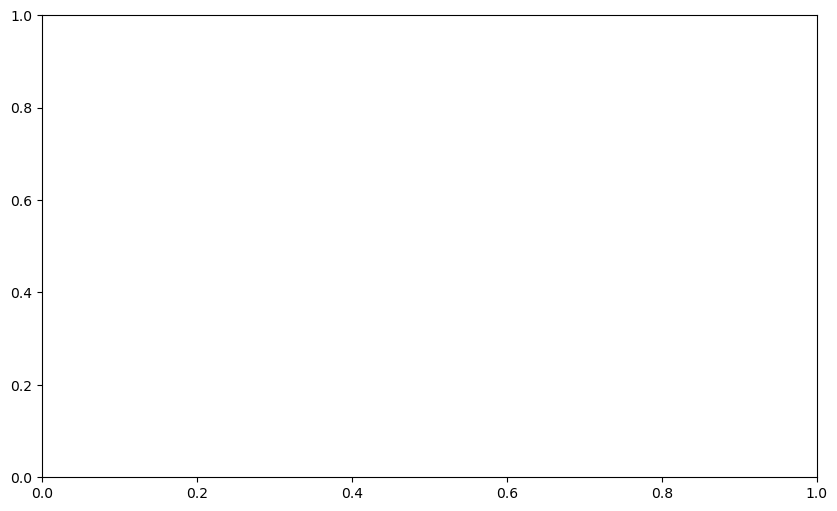

In [ ]:
import os
import glob
import gc
import pickle
import numpy as np
import pandas as pd
import networkx as nx
import geopandas as gpd
import osmnx as ox
import igraph as ig
import matplotlib.pyplot as plt
import concurrent.futures
from joblib import Parallel, delayed

# ==========================================
# 1. SETUP & PATHS
# ==========================================
places = ["newcastle", "north_tyneside", "south_tyneside", "sunderland", "gateshead"]
base_dir = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external"
debug_dir = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\debugging"
os.makedirs(debug_dir, exist_ok=True)

lts_mapping = {
    "motorway": 4, "motorway_link": 4, "trunk": 4, "trunk_link": 4,
    "primary": 4, "primary_link": 4, "secondary": 4, "secondary_link": 4,
    "tertiary": 3, "tertiary_link": 3, "unclassified": 3,
    "residential": 2, "living_street": 2,
    "cycleway": 1, "track": 1, "path": 1, "bridleway": 1, "footway": 1, "pedestrian": 1
}

# ==========================================
# 2. CORE FUNCTIONS
# ==========================================
def load_scenario_data(filepath):
    if not os.path.exists(filepath):
        return [], []
    with open(filepath, "rb") as f:
        data = pickle.load(f)
    gts = data.get("GTs", [])
    abstracts = data.get("GT_abstracts", [])
    gts.insert(0, nx.MultiGraph())
    abstracts.insert(0, nx.MultiGraph())
    return gts, abstracts

def parse_and_group_trips_for_igraph(od_demand, exit_points, osmid_to_idx):
    exit_dict = exit_points.groupby('neighbourhood_id')['osmid'].apply(
        lambda x: [osmid_to_idx[o] for o in x if o in osmid_to_idx]
    ).to_dict()

    grouped_trips = {}
    for _, row in od_demand.iterrows():
        if pd.isna(row['start_osmid']) or row['total_flow'] <= 0:
            continue
            
        s_idxs = exit_dict.get(int(row['start_neighbourhood_id']), []) if row.get('ltn_origin') else []
        if not s_idxs and row['start_osmid'] in osmid_to_idx:
            s_idxs = [osmid_to_idx[row['start_osmid']]]
            
        e_idxs = exit_dict.get(int(row['end_neighbourhood_id']), []) if row.get('ltn_destination') else []
        if not e_idxs and row['end_osmid'] in osmid_to_idx:
            e_idxs = [osmid_to_idx[row['end_osmid']]]
            
        if s_idxs and e_idxs:
            s_tuple = tuple(sorted(s_idxs))
            if s_tuple not in grouped_trips:
                grouped_trips[s_tuple] = []
            grouped_trips[s_tuple].append({'ends': e_idxs, 'flow': row['total_flow']})

    return grouped_trips

def get_path_lts_metrics_igraph(results_gts, g_base_ig, grouped_trips, osmid_to_idx):
    """Calculates mean, max, and min LTS of shortest paths across all OD pairs."""
    g_scenario = g_base_ig.copy()
    
    # Pre-allocate all possible edges across all stages
    all_new_edges = {}
    for G_routed in results_gts:
        if G_routed is not None:
            for u, v, k, d in G_routed.edges(keys=True, data=True):
                if u in osmid_to_idx and v in osmid_to_idx:
                    u_idx, v_idx = osmid_to_idx[u], osmid_to_idx[v]
                    raw_len = d.get('length', 0)
                    edge_len = float(raw_len if isinstance(raw_len, list) else raw_len)
                    all_new_edges[(u_idx, v_idx)] = edge_len

    edges_to_add = list(all_new_edges.keys())
    g_scenario.add_edges(edges_to_add)
    
    start_idx = g_scenario.ecount() - len(edges_to_add)
    edge_lookup = {}
    for idx, ((u_idx, v_idx), length) in enumerate(all_new_edges.items()):
        ig_edge_id = start_idx + idx
        g_scenario.es[ig_edge_id]['lts_length'] = float('inf') 
        g_scenario.es[ig_edge_id]['lts_class'] = 1 
        g_scenario.es[ig_edge_id]['actual_length'] = length
        edge_lookup[(u_idx, v_idx)] = ig_edge_id

    perfect_paths = {} 
    avg_lts_per_stage, max_lts_per_stage, min_lts_per_stage = [], [], []

    for i, G_routed in enumerate(results_gts):
        for ig_edge_id in edge_lookup.values():
            g_scenario.es[ig_edge_id]['lts_length'] = float('inf')
            
        if G_routed is not None:
            for u, v, k, d in G_routed.edges(keys=True, data=True):
                if u in osmid_to_idx and v in osmid_to_idx:
                    u_idx, v_idx = osmid_to_idx[u], osmid_to_idx[v]
                    if (u_idx, v_idx) in edge_lookup:
                        ig_edge_id = edge_lookup[(u_idx, v_idx)]
                        actual_length = g_scenario.es[ig_edge_id]['actual_length']
                        g_scenario.es[ig_edge_id]['lts_length'] = actual_length * 1 

        lts_lengths_fast = g_scenario.es['lts_length']
        lts_classes_fast = g_scenario.es['lts_class']

        stage_mean_lts, stage_max_lts, stage_min_lts = [], [], []
        
        for s_tuple, destinations in grouped_trips.items():
            unique_ends = list(set(e for d in destinations for e in d['ends']))
            if not unique_ends: continue
            
            ends_to_route = [e for e in unique_ends if (s_tuple, e) not in perfect_paths]
            all_paths = []
            if ends_to_route:
                for src_node in s_tuple:
                    paths = g_scenario.get_shortest_paths(
                        v=src_node, to=ends_to_route, weights='lts_length', output='epath'
                    )
                    all_paths.append(paths)

            route_idx = 0
            for e in unique_ends:
                if (s_tuple, e) in perfect_paths:
                    mean_val, max_val, min_val = perfect_paths[(s_tuple, e)]
                    stage_mean_lts.append(mean_val)
                    stage_max_lts.append(max_val)
                    stage_min_lts.append(min_val)
                else:
                    candidate_paths = [
                        all_paths[src_idx][route_idx]
                        for src_idx in range(len(s_tuple))
                        if all_paths[src_idx][route_idx]
                    ]
                    route_idx += 1 
                    
                    if not candidate_paths:
                        continue

                    best_path = min(
                        candidate_paths,
                        key=lambda path: sum(lts_lengths_fast[edge_id] for edge_id in path)
                    )

                    if not best_path:
                        continue

                    lts_classes = [lts_classes_fast[edge_id] for edge_id in best_path]
                    mean_val = np.mean(lts_classes)
                    max_val = np.max(lts_classes)
                    min_val = np.min(lts_classes)
                    
                    stage_mean_lts.append(mean_val)
                    stage_max_lts.append(max_val)
                    stage_min_lts.append(min_val)
                    
                    if mean_val == 1.0:
                        perfect_paths[(s_tuple, e)] = (mean_val, max_val, min_val)
        
        if stage_mean_lts:
            avg_lts_per_stage.append(np.mean(stage_mean_lts))
            max_lts_per_stage.append(np.mean(stage_max_lts))
            min_lts_per_stage.append(np.mean(stage_min_lts))
        else:
            avg_lts_per_stage.append(0)
            max_lts_per_stage.append(0)
            min_lts_per_stage.append(0)

    return avg_lts_per_stage, max_lts_per_stage, min_lts_per_stage

# Worker function for Main Scenarios (Threading)
def process_scenario_thread(args):
    name, path, g_base_ig, grouped_trips, osmid_to_idx = args
    gts, _ = load_scenario_data(path)
    if not gts: 
        return name, None, None, None, None
    stages = list(range(len(gts)))
    avg_lts, max_lts, min_lts = get_path_lts_metrics_igraph(gts, g_base_ig, grouped_trips, osmid_to_idx)
    return name, avg_lts, max_lts, min_lts, stages

# Worker function for Random Runs (Joblib)
def process_single_random_run_lts(filepath, g_base_ig, grouped_trips, osmid_to_idx):
    r_gts, _ = load_scenario_data(filepath)
    if not r_gts: return None
    r_avg, r_max, r_min = get_path_lts_metrics_igraph(r_gts, g_base_ig, grouped_trips, osmid_to_idx)
    return (r_avg, r_max, r_min)

def plot_lts_metrics(stages, scenario_dict, random_lists, title, ylabel, save_path):
    plt.figure(figsize=(10, 6))
    
    # Plot random lines first so they are in the background
    if random_lists is not None and len(random_lists) > 0:
        for i, r_flows in enumerate(random_lists):
            plt.plot(stages, r_flows, color='grey', alpha=0.05, linewidth=1.5, label='Random (Individual)' if i == 0 else None)
        plt.plot(stages, np.mean(random_lists, axis=0), color='blue', linestyle='--', linewidth=2.5, label='Random (Mean)')

    colors = {'Demand': 'red', 'Betweenness': 'orange', 'Demand LTN Priority': 'green', 'Betweenness LTN Priority': 'purple'}
    linestyles = {'Demand': '--', 'Betweenness': '-', 'Demand LTN Priority': '-.', 'Betweenness LTN Priority': '-'}
    
    for name, data in scenario_dict.items():
        if data:
            plt.plot(stages[:len(data)], data, color=colors.get(name, 'black'), linestyle=linestyles.get(name, '-'), linewidth=2.5, label=name)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Infrastructure Added (Stages)", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right', fontsize=10) # Upper right generally better for LTS as values start high and drop
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()


# ==========================================
# 3. GLOBAL STORAGE FOR MASTER PLOTS
# ==========================================
global_main_avg = { 'Demand': [], 'Betweenness': [], 'Demand LTN Priority': [], 'Betweenness LTN Priority': [] }
global_main_max = { 'Demand': [], 'Betweenness': [], 'Demand LTN Priority': [], 'Betweenness LTN Priority': [] }
global_main_min = { 'Demand': [], 'Betweenness': [], 'Demand LTN Priority': [], 'Betweenness LTN Priority': [] }

global_random_avg = []
global_random_max = []
global_random_min = []

# ==========================================
# 4. MAIN EXECUTION LOOP
# ==========================================
for place in places:
    print(f"\n{'='*50}\nTracking Path LTS Metrics for: {place.upper()}\n{'='*50}")
    
    results_dir = os.path.join(base_dir, "results", place, "current_ltn_scenario")
    data_dir = os.path.join(base_dir, "data", place, "current_ltn_scenario")
    exports_dir = os.path.join(base_dir, "exports_gpkg", place, "current_ltn_scenario")
    
    # ---------------------------------------------------------
    # A. Load Spatial Data & Demand
    # ---------------------------------------------------------
    print("Loading base spatial and demand data...")
    od_demand = gpd.read_file(os.path.join(data_dir, f"{place}_current_ltn_scenario_greedy_demand_weighted.gpkg"))
    exit_points = gpd.read_file(os.path.join(exports_dir, f"{place}_exit_points.gpkg"))
    ltns = gpd.read_file(os.path.join(data_dir, f"scored_neighbourhoods_{place}.gpkg"))
    
    bikeable_gpkg = os.path.join(data_dir, f"{place}_biketrackcarall.gpkg")
    G_base = ox.graph_from_gdfs(
        gpd.read_file(bikeable_gpkg, layer="nodes").set_index("osmid"), 
        gpd.read_file(bikeable_gpkg, layer="edges").set_index(["u", "v", "key"])
    )
    
    start_points = od_demand['geometry'].apply(lambda line: line.interpolate(0, normalized=True) if line is not None else None)
    end_points = od_demand['geometry'].apply(lambda line: line.interpolate(1, normalized=True) if line is not None else None)
    gdf_starts = gpd.GeoDataFrame(geometry=start_points, crs=od_demand.crs)
    gdf_ends = gpd.GeoDataFrame(geometry=end_points, crs=od_demand.crs)
    
    if ltns.crs != od_demand.crs: ltns = ltns.to_crs(od_demand.crs)
    ltns_clean = ltns.drop(columns=['index_left', 'index_right'], errors='ignore').copy()
    ltns_clean['neighbourhood_id'] = ltns_clean.index

    starts_joined = gpd.sjoin(gdf_starts, ltns_clean, how='left', predicate='intersects')
    ends_joined = gpd.sjoin(gdf_ends, ltns_clean, how='left', predicate='intersects')
    starts_joined = starts_joined[~starts_joined.index.duplicated(keep='first')]
    ends_joined = ends_joined[~ends_joined.index.duplicated(keep='first')]

    od_demand['start_neighbourhood_id'] = starts_joined['neighbourhood_id']
    od_demand['end_neighbourhood_id'] = ends_joined['neighbourhood_id']
    od_demand['ltn_origin'] = od_demand['start_neighbourhood_id'].notna()
    od_demand['ltn_destination'] = od_demand['end_neighbourhood_id'].notna()
    
    # ---------------------------------------------------------
    # B. Assign Initial LTS Values to Graph
    # ---------------------------------------------------------
    _, edges_gdf = ox.graph_to_gdfs(G_base)
    if edges_gdf.crs != ltns.crs: ltns = ltns.to_crs(edges_gdf.crs)
    edges_gdf = edges_gdf.drop(columns=['index_left', 'index_right'], errors='ignore')
    ltns = ltns.drop(columns=['index_left', 'index_right'], errors='ignore')
    
    edges_in_ltn = gpd.sjoin(edges_gdf, ltns, how='inner', predicate='intersects')
    ltn_edge_indices = set(edges_in_ltn.index)
    nx.set_edge_attributes(G_base, {(u, v, k): ((u, v, k) in ltn_edge_indices) for u, v, k in G_base.edges(keys=True)}, 'ltn_flag')

    for u, v, key, data in G_base.edges(keys=True, data=True):
        is_ltn = data.get('ltn_flag')
        lts_class = 1 if (is_ltn is True or str(is_ltn).lower() == 'true') else lts_mapping.get(data.get('highway', ['']) if isinstance(data.get('highway'), list) else data.get('highway'), 4)
        data['lts_class'] = lts_class
        data['lts_length'] = data.get('length', 0) * lts_class 

    g_base_ig = ig.Graph.from_networkx(G_base.to_undirected())
    osmid_to_idx = {osmid: idx for idx, osmid in enumerate(g_base_ig.vs['_nx_name'])}
    
    print("Pre-parsing Trips...")
    grouped_trips = parse_and_group_trips_for_igraph(od_demand, exit_points, osmid_to_idx)

    # ---------------------------------------------------------
    # C. Main Scenarios Execution
    # ---------------------------------------------------------
    scenario_paths = {
        'Demand': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_demand_weighted_current_ltn_scenario.pickle"),
        'Betweenness': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_betweenness_weighted_current_ltn_scenario.pickle"),
        'Demand LTN Priority': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_demand_ltn_priority_weighted_current_ltn_scenario.pickle"),
        'Betweenness LTN Priority': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_betweenness_ltn_priority_weighted_current_ltn_scenario.pickle")
    }

    results_avg_lts = {}
    results_max_lts = {}
    results_min_lts = {}
    master_stages = None

    print("Routing main scenarios simultaneously...")
    thread_args = [
        (name, path, g_base_ig, grouped_trips, osmid_to_idx)
        for name, path in scenario_paths.items()
    ]
    
    with concurrent.futures.ThreadPoolExecutor(max_workers=4) as executor:
        for name, avg_lts, max_lts, min_lts, s in executor.map(process_scenario_thread, thread_args):
            if avg_lts:
                print(f"  -> Finished routing for {name}")
                results_avg_lts[name] = avg_lts
                results_max_lts[name] = max_lts
                results_min_lts[name] = min_lts
                if master_stages is None and s is not None:
                    master_stages = s

    # ---------------------------------------------------------
    # D. Random Scenarios Execution (PARALLEL)
    # ---------------------------------------------------------
    random_files = sorted(glob.glob(os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_random_weighted_current_ltn_scenario_run*.pickle")))
    print(f"Evaluating {len(random_files)} Random Runs in parallel across CPU cores...")
    
    parallel_results = Parallel(n_jobs=4, verbose=10)(
        delayed(process_single_random_run_lts)(f, g_base_ig, grouped_trips, osmid_to_idx) 
        for f in random_files
    )
    
    valid_results = [res for res in parallel_results if res is not None]
    
    # Correctly unpack the tuples returned by the process_single_random_run_lts function
    random_avg_all = [res[0] for res in valid_results]
    random_max_all = [res[1] for res in valid_results]
    random_min_all = [res[2] for res in valid_results]

    # ---------------------------------------------------------
    # E. Save Local Plots & Append to Global
    # ---------------------------------------------------------
    print(f"Generating Plots and saving data for {place}...")
    
    if master_stages is not None:
        plot_lts_metrics(master_stages, results_avg_lts, random_avg_all, f"{place.title()} - Average LTS of Shortest Paths", "Mean Path LTS", os.path.join(debug_dir, f"{place}_path_avg_lts.png"))
        plot_lts_metrics(master_stages, results_max_lts, random_max_all, f"{place.title()} - Maximum LTS of Shortest Paths", "Mean of Max Path LTS", os.path.join(debug_dir, f"{place}_path_max_lts.png"))
        plot_lts_metrics(master_stages, results_min_lts, random_min_all, f"{place.title()} - Minimum LTS of Shortest Paths", "Mean of Min Path LTS", os.path.join(debug_dir, f"{place}_path_min_lts.png"))

        # Dump local pickle file 
        place_data_path = os.path.join(debug_dir, f"{place}_path_lts_data.pickle")
        with open(place_data_path, "wb") as f:
            pickle.dump({
                "stages": master_stages,
                "results_avg_lts": results_avg_lts,
                "results_max_lts": results_max_lts,
                "results_min_lts": results_min_lts,
                "random_avg_all": random_avg_all,
                "random_max_all": random_max_all,
                "random_min_all": random_min_all
            }, f)
        print(f"💾 {place.title()} data securely saved to: {place_data_path}")

        # Append to globals for master plotting
        for name in results_avg_lts.keys():
            global_main_avg[name].append(results_avg_lts[name])
            global_main_max[name].append(results_max_lts[name])
            global_main_min[name].append(results_min_lts[name])

        global_random_avg.append(random_avg_all)
        global_random_max.append(random_max_all)
        global_random_min.append(random_min_all)

    del G_base, g_base_ig, od_demand
    gc.collect()

print("\n" + "="*50)
print("ALL LOCATIONS PROCESSED. GENERATING OVERALL REGIONAL PLOTS...")
print("="*50)

# ==========================================
# 5. OVERALL REGIONAL PLOTS & AUC
# ==========================================

# 1. Average main scenarios across all 5 places
final_main_avg = {name: np.mean(global_main_avg[name], axis=0) for name in global_main_avg}
final_main_max = {name: np.mean(global_main_max[name], axis=0) for name in global_main_max}
final_main_min = {name: np.mean(global_main_min[name], axis=0) for name in global_main_min}

# 2. Average the 100 Random Runs across all 5 places
final_random_avg = np.mean(np.vstack(global_random_avg), axis=0)
final_random_max = np.mean(np.vstack(global_random_max), axis=0)
final_random_min = np.mean(np.vstack(global_random_min), axis=0)

# Generate Regional Plots
plot_lts_metrics(master_stages, final_main_avg, final_random_avg, "Overall Region Results - Average LTS", "Mean Path LTS", os.path.join(debug_dir, "OVERALL_path_avg_lts.png"))
plot_lts_metrics(master_stages, final_main_max, final_random_max, "Overall Region Results - Maximum LTS", "Mean of Max Path LTS", os.path.join(debug_dir, "OVERALL_path_max_lts.png"))
plot_lts_metrics(master_stages, final_main_min, final_random_min, "Overall Region Results - Minimum LTS", "Mean of Min Path LTS", os.path.join(debug_dir, "OVERALL_path_min_lts.png"))
print("\n🎉 MASTER PLOTS GENERATED SUCCESSFULLY!")

# Dump Master Data Pickle
master_data_path = os.path.join(debug_dir, "OVERALL_REGION_LTS_METRICS_DATA.pickle")
with open(master_data_path, "wb") as f:
    pickle.dump({
        "stages": master_stages,
        "final_main_avg": final_main_avg,
        "final_main_max": final_main_max,
        "final_main_min": final_main_min,
        "final_random_avg": final_random_avg,
        "final_random_max": final_random_max,
        "final_random_min": final_random_min
    }, f)
print(f"💾 Regional data securely saved to: {master_data_path}")


# ==========================================
# CUMULATIVE BENEFIT (AREA UNDER THE CURVE)
# ==========================================
auc_output_path = os.path.join(debug_dir, "OVERALL_REGION_LTS_AUC_LEADERBOARD.txt")

def generate_auc_report_lts(metric_name, x_axis, main_dict, random_matrix):
    lines = []
    lines.append(f"\n--- {metric_name} ---")
    
    scores = {}
    for name, y_data in main_dict.items():
        scores[name] = np.trapz(y_data, x=x_axis)
        
    random_mean_line = np.mean(random_matrix, axis=0)
    scores['Random (Mean)'] = np.trapz(random_mean_line, x=x_axis)
    
    baseline_name = 'Random (Mean)'
    baseline_auc = scores[baseline_name]
    
    # Sort from LOWEST AUC to HIGHEST (For LTS, a smaller area means stress dropped faster)
    sorted_scores = sorted(scores.items(), key=lambda item: item)
    
    for rank, (name, auc) in enumerate(sorted_scores, 1):
        if name == baseline_name:
            pct_str = " (BASELINE)"
        else:
            if baseline_auc != 0:
                pct_diff = ((auc - baseline_auc) / baseline_auc) * 100
                # If negative, the AUC is lower than baseline (which is GOOD for LTS)
                word = "Better" if pct_diff < 0 else "Worse" 
                pct_str = f" | {abs(pct_diff):.2f}% {word} than {baseline_name}"
            else:
                pct_str = ""

        lines.append(f"{rank}. {name:<26} | AUC: {auc:,.1f} (LTS-Stages){pct_str}")
            
    return "\n".join(lines)

report_content = []
report_content.append("="*85)
report_content.append("🏆 REGIONAL LEADERBOARD: AREA UNDER THE CURVE (AUC) 🏆")
report_content.append("Note: For LTS metrics, LOWER AUC = Faster network stress reduction (BETTER)")
report_content.append("="*85)

report_content.append(generate_auc_report_lts("Average Path LTS", master_stages, final_main_avg, final_random_avg))
report_content.append(generate_auc_report_lts("Maximum Path LTS", master_stages, final_main_max, final_random_max))

report_content.append("\n" + "="*85)

final_text = "\n".join(report_content)
print(final_text)

with open(auc_output_path, "w", encoding="utf-8") as f:
    f.write(final_text)

print(f"\n📄 LTS Leaderboard successfully saved to: {auc_output_path}")
print("\n🎉 ALL LTS METRICS AND PLOTS GENERATED SUCCESSFULLY!")

-----------------------

# edge rankings

Demand: loaded 100 graphs
Betweenness: loaded 100 graphs
Demand LTN Priority: loaded 100 graphs
Betweenness LTN Priority: loaded 100 graphs
Common edges across all methods: 8412
Earliest agreement iteration: 3
Number of first common edges: 7


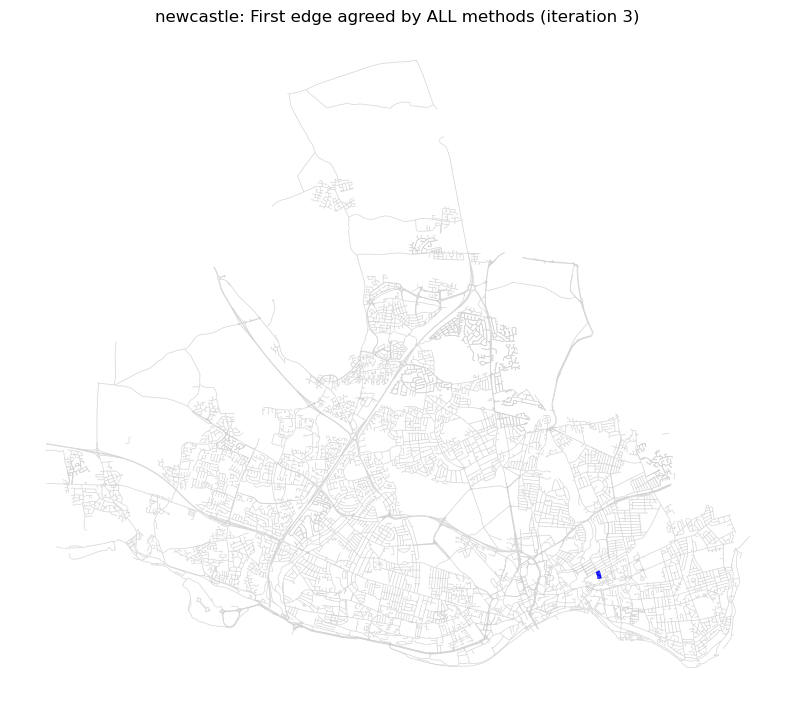


Running ABSTRACT for: newcastle
Demand: loaded 100 abstract graphs
Betweenness: loaded 100 abstract graphs
Demand LTN Priority: loaded 100 abstract graphs
Betweenness LTN Priority: loaded 100 abstract graphs
Common abstract edges: 232
Earliest abstract agreement iteration: 3
Number of edges: 1
Plotting abstract edge: (345643357, 776327170)


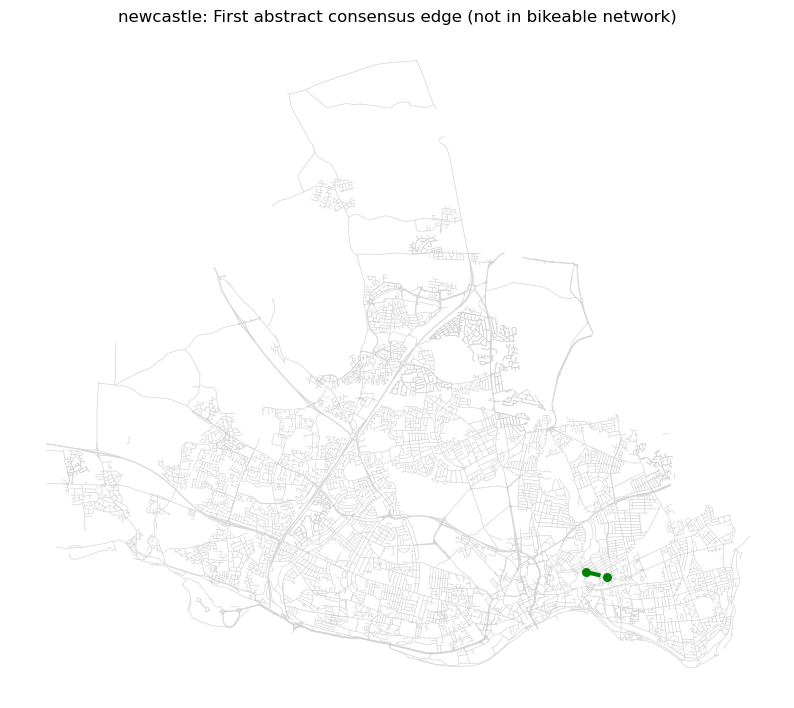

Shared abstract edges: 232
Plotting 50 edges


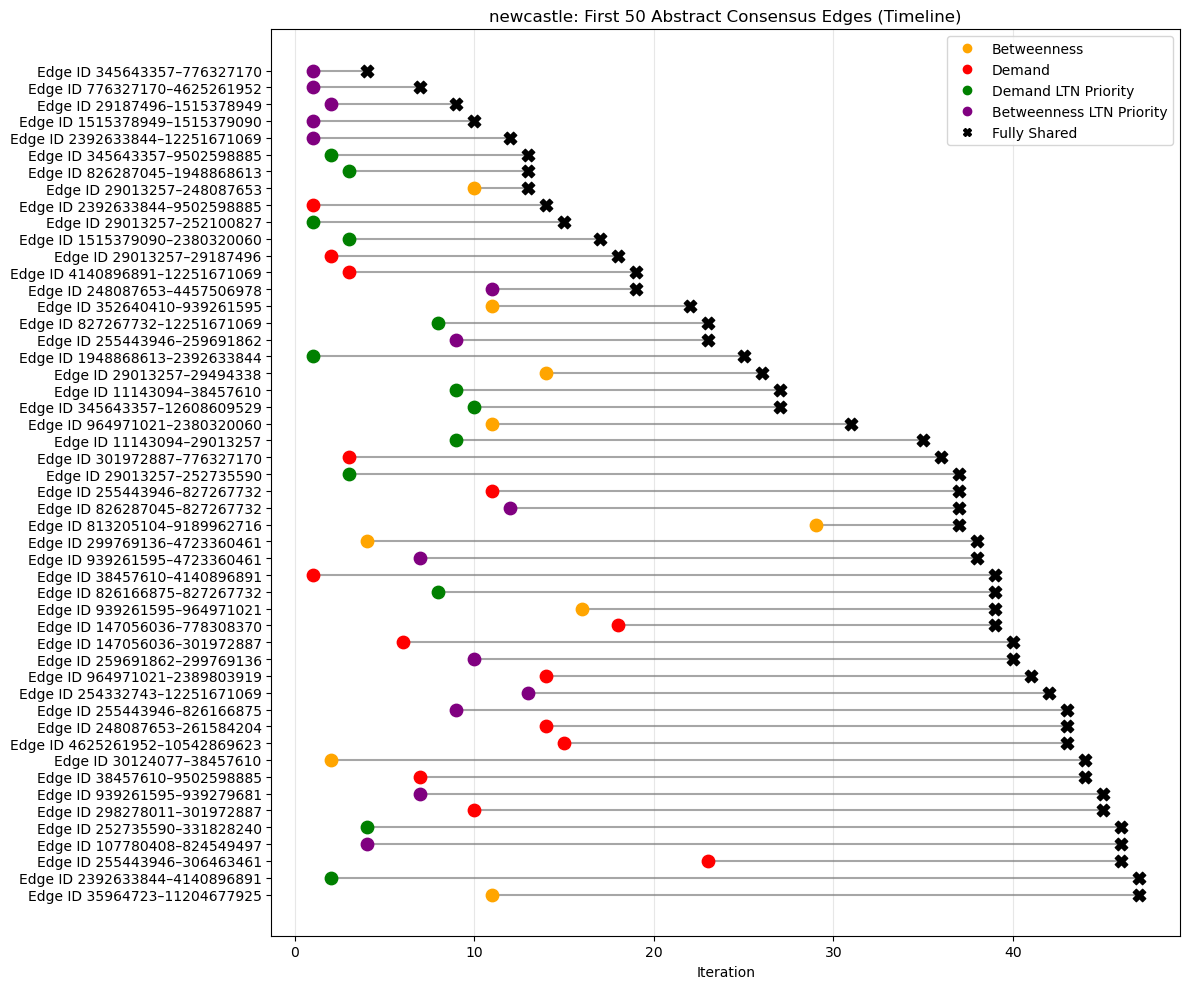

Demand: loaded 100 graphs
Betweenness: loaded 100 graphs
Demand LTN Priority: loaded 100 graphs
Betweenness LTN Priority: loaded 100 graphs
Common edges across all methods: 8110
Earliest agreement iteration: 4
Number of first common edges: 53


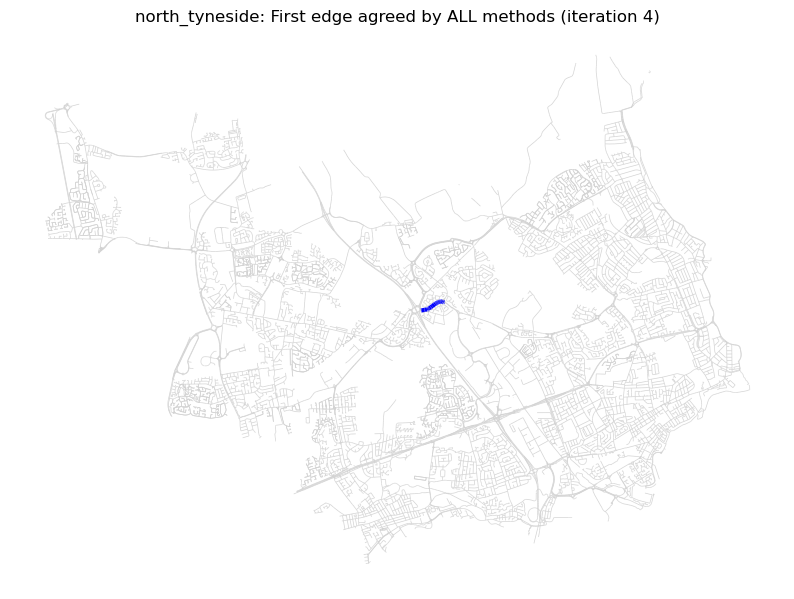


Running ABSTRACT for: north_tyneside
Demand: loaded 100 abstract graphs
Betweenness: loaded 100 abstract graphs
Demand LTN Priority: loaded 100 abstract graphs
Betweenness LTN Priority: loaded 100 abstract graphs
Common abstract edges: 189
Earliest abstract agreement iteration: 1
Number of edges: 1
Plotting abstract edge: (851733186, 5927246077)


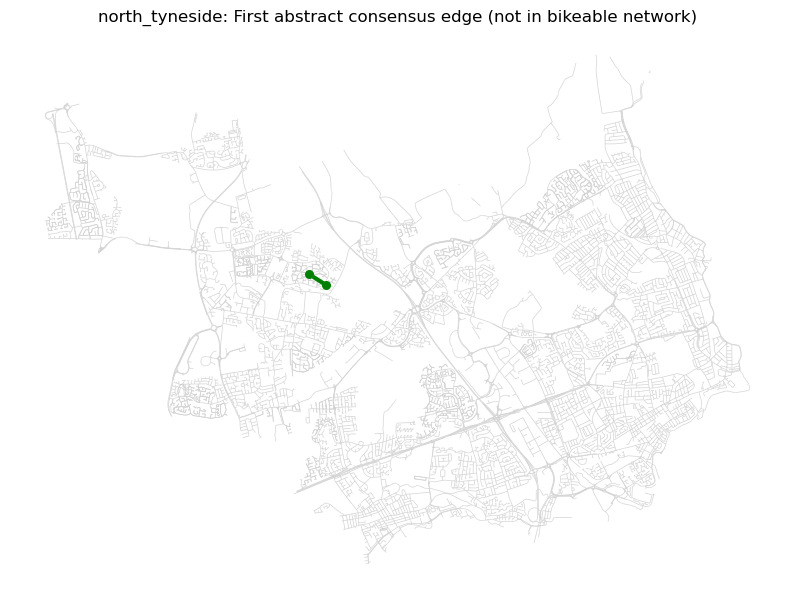

Shared abstract edges: 189
Plotting 50 edges


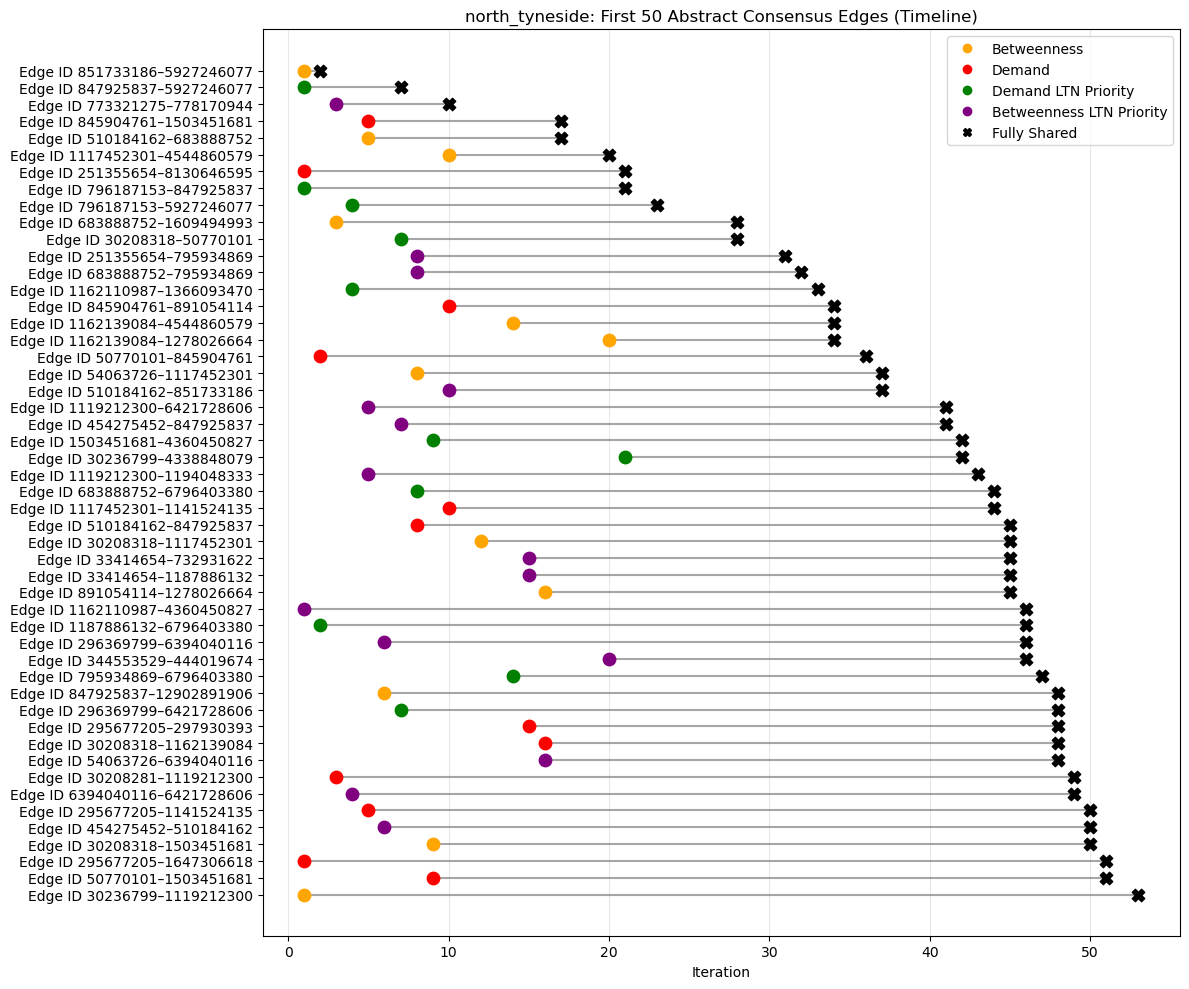

Demand: loaded 100 graphs
Betweenness: loaded 100 graphs
Demand LTN Priority: loaded 100 graphs
Betweenness LTN Priority: loaded 100 graphs
Common edges across all methods: 4706
Earliest agreement iteration: 1
Number of first common edges: 20


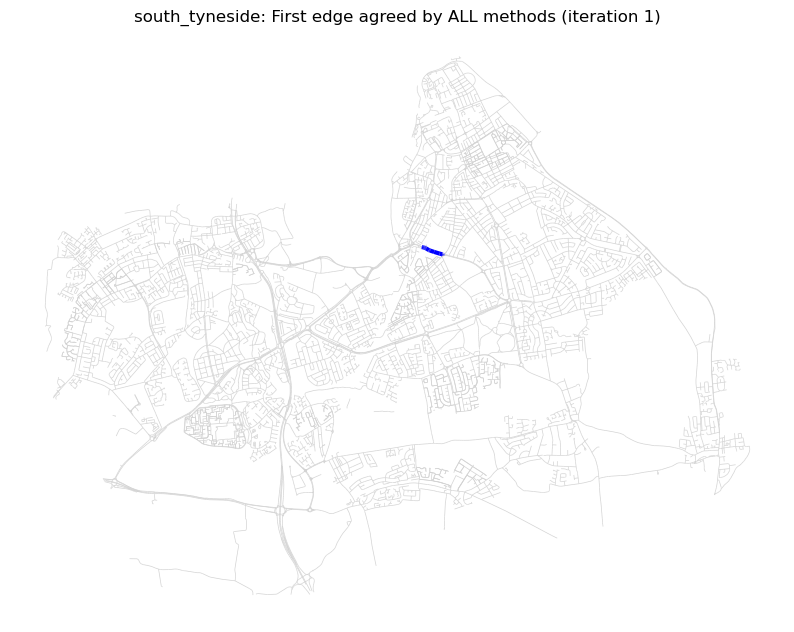


Running ABSTRACT for: south_tyneside
Demand: loaded 100 abstract graphs
Betweenness: loaded 100 abstract graphs
Demand LTN Priority: loaded 100 abstract graphs
Betweenness LTN Priority: loaded 100 abstract graphs
Common abstract edges: 136
Earliest abstract agreement iteration: 1
Number of edges: 1
Plotting abstract edge: (1278126296, 1278193451)


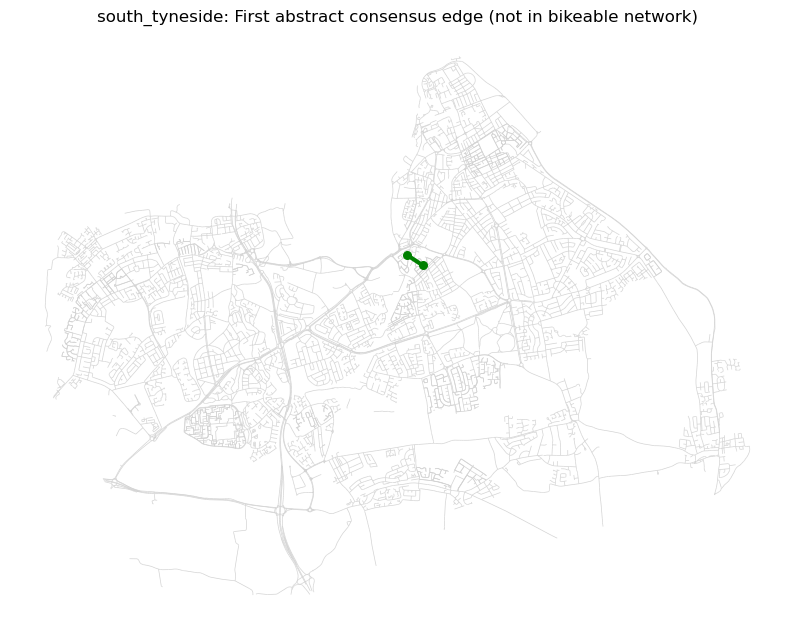

Shared abstract edges: 136
Plotting 50 edges


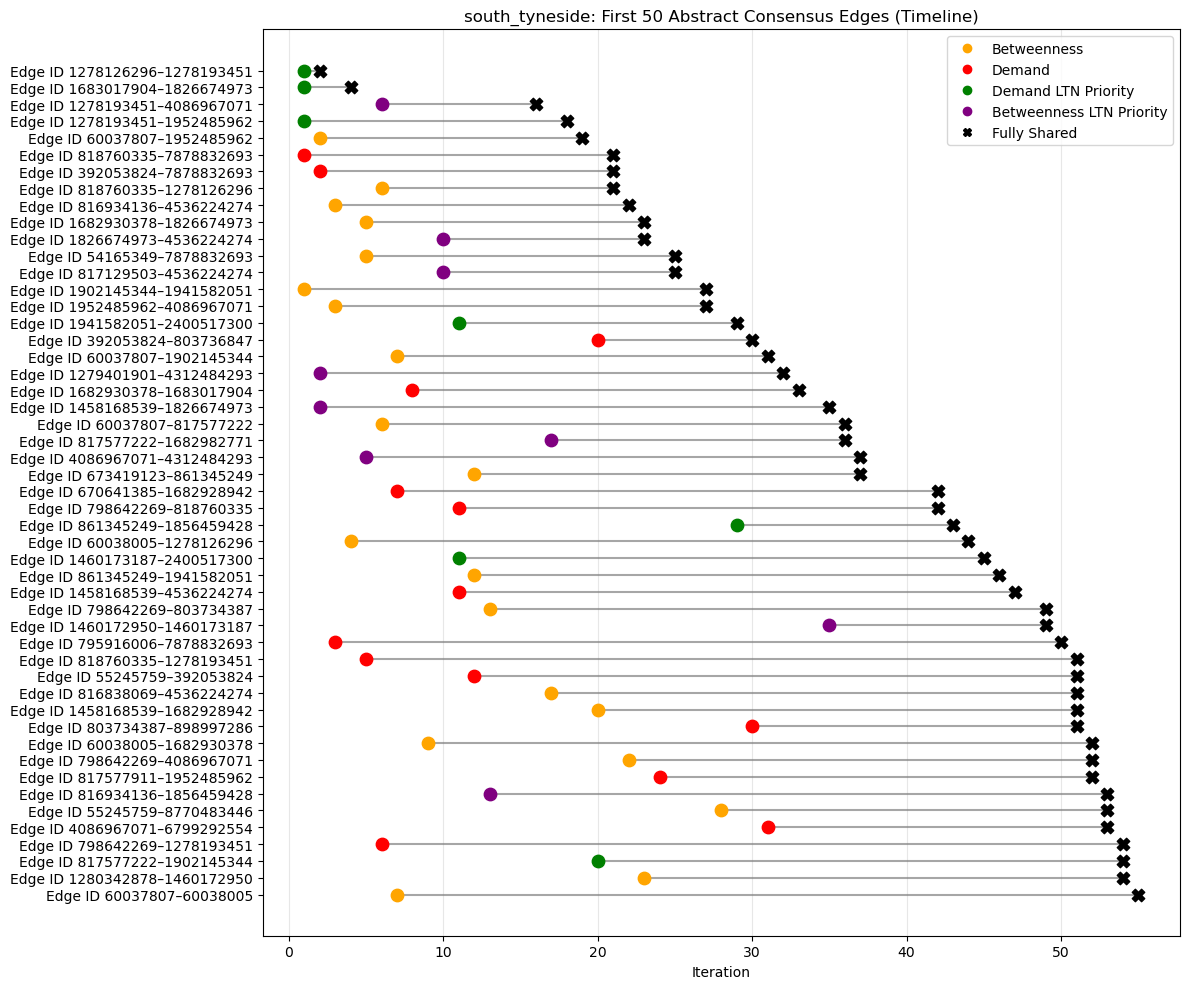

Demand: loaded 100 graphs
Betweenness: loaded 100 graphs
Demand LTN Priority: loaded 100 graphs
Betweenness LTN Priority: loaded 100 graphs
Common edges across all methods: 10374
Earliest agreement iteration: 6
Number of first common edges: 88


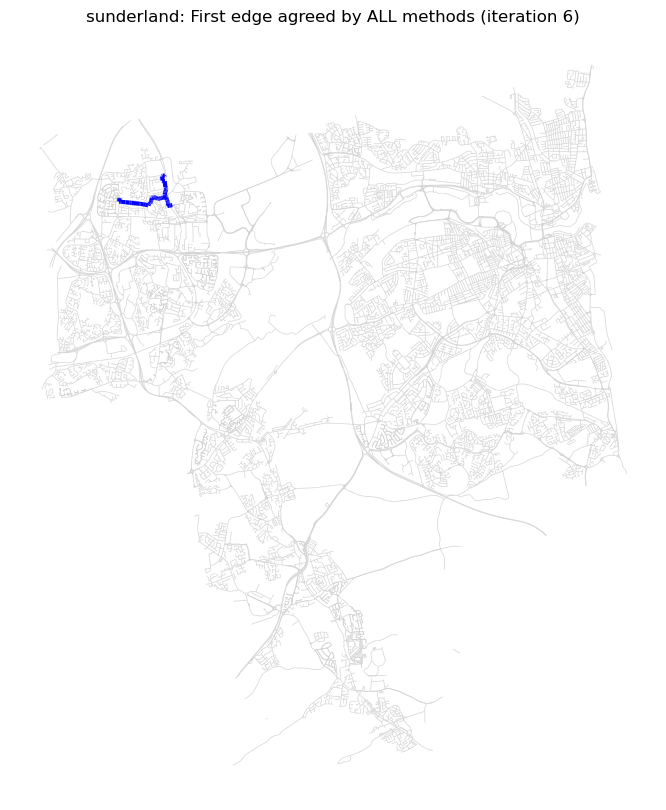


Running ABSTRACT for: sunderland
Demand: loaded 100 abstract graphs
Betweenness: loaded 100 abstract graphs
Demand LTN Priority: loaded 100 abstract graphs
Betweenness LTN Priority: loaded 100 abstract graphs
Common abstract edges: 319
Earliest abstract agreement iteration: 1
Number of edges: 1
Plotting abstract edge: (348749149, 391438314)


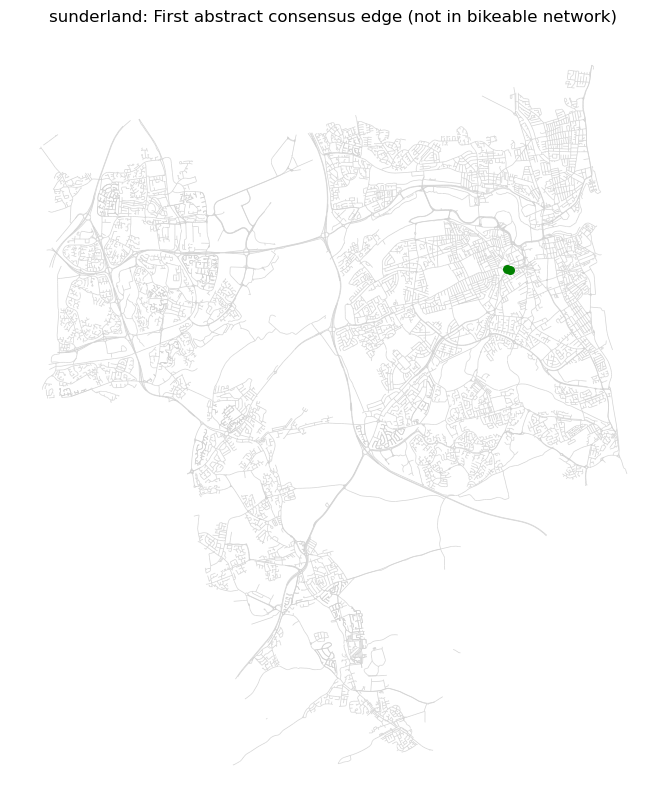

Shared abstract edges: 319
Plotting 50 edges


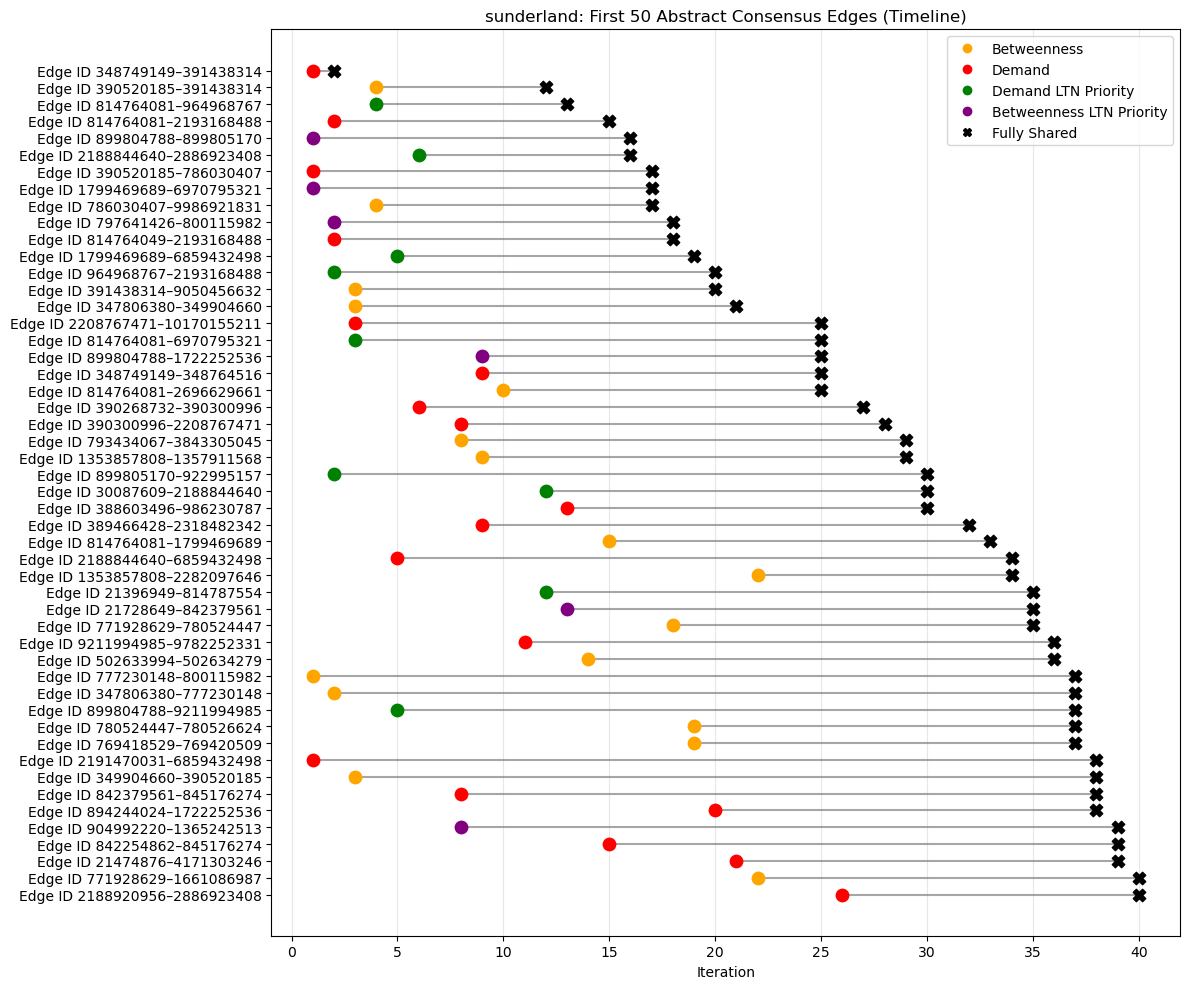

Demand: loaded 100 graphs
Betweenness: loaded 100 graphs
Demand LTN Priority: loaded 100 graphs
Betweenness LTN Priority: loaded 100 graphs
Common edges across all methods: 8032
Earliest agreement iteration: 2
Number of first common edges: 6


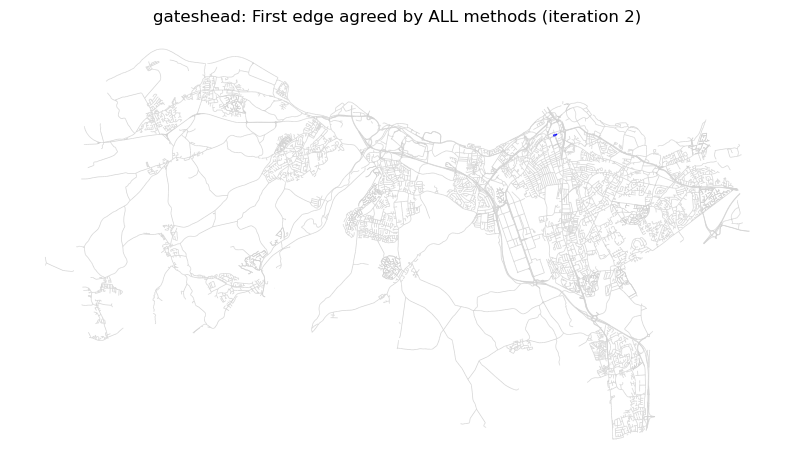


Running ABSTRACT for: gateshead
Demand: loaded 100 abstract graphs
Betweenness: loaded 100 abstract graphs
Demand LTN Priority: loaded 100 abstract graphs
Betweenness LTN Priority: loaded 100 abstract graphs
Common abstract edges: 222
Earliest abstract agreement iteration: 3
Number of edges: 1
Plotting abstract edge: (986339017, 4366478736)


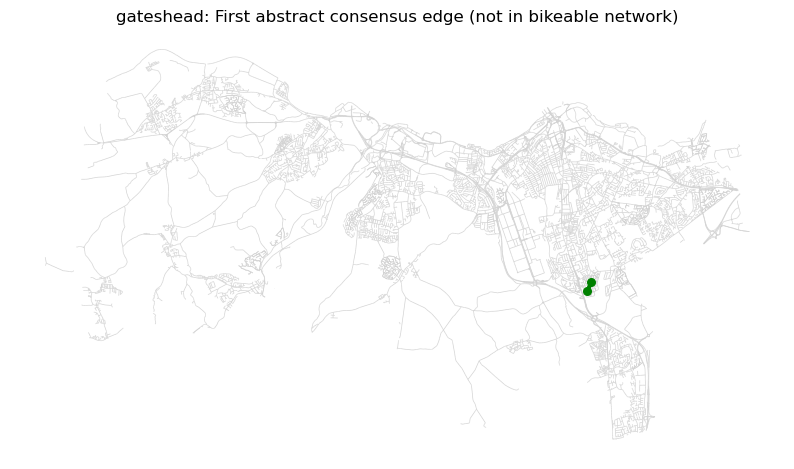

Shared abstract edges: 222
Plotting 50 edges


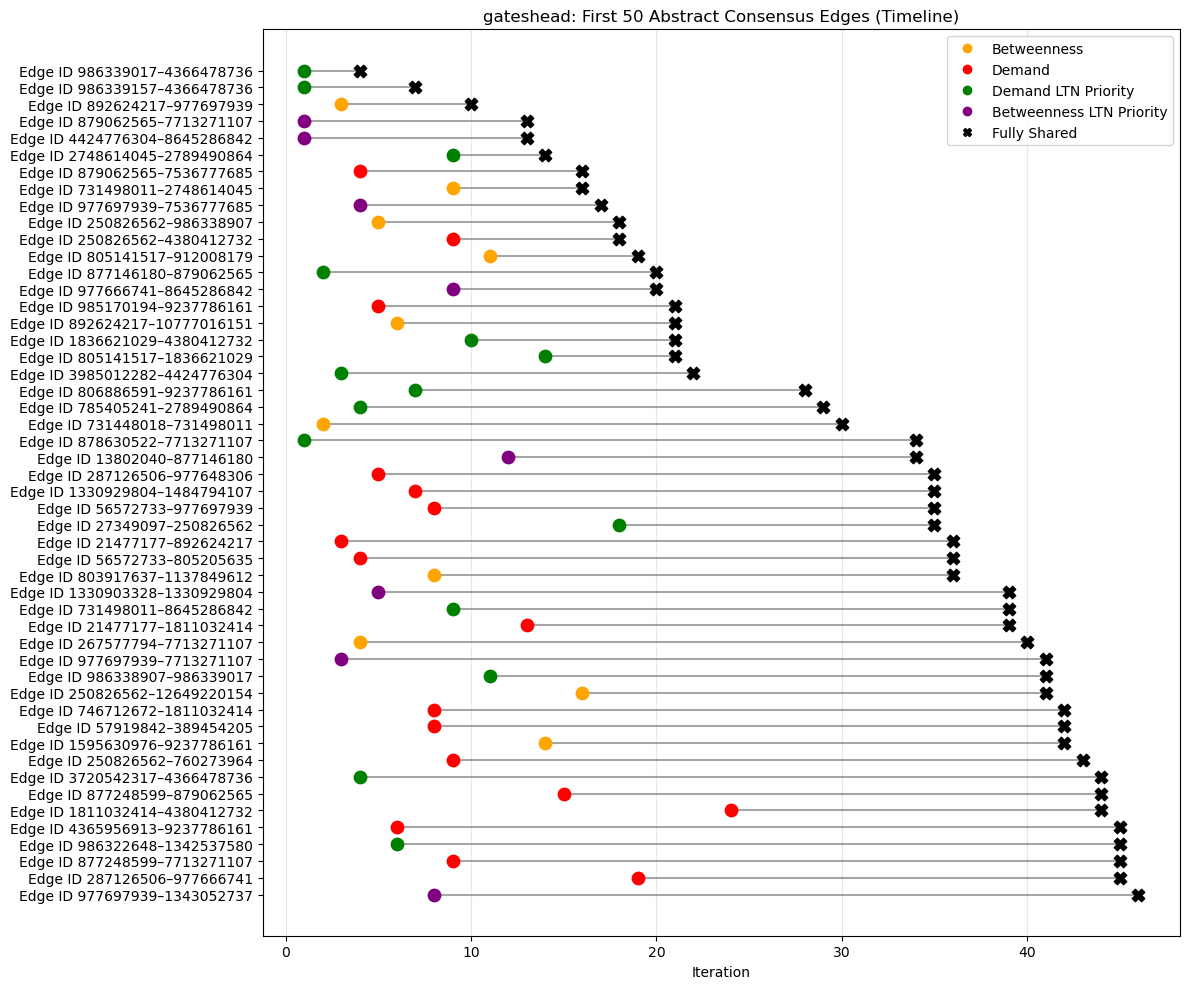

In [23]:
import os
import pickle
import networkx as nx
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt


places = ["newcastle", "north_tyneside", "south_tyneside", "sunderland", "gateshead"]
base_dir = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\unforked\bikenwgrowth_external"
debug_dir = r"C:\Users\b8008458\OneDrive - Newcastle University\2022 to 2023\PhD\networkGrowth\debugging"
os.makedirs(debug_dir, exist_ok=True)
for place in places:
    results_dir = os.path.join(base_dir, "results", place, "current_ltn_scenario")
    data_dir = os.path.join(base_dir, "data", place, "current_ltn_scenario")
    exports_dir = os.path.join(base_dir, "exports_gpkg", place, "current_ltn_scenario")
    paths = {
        'Demand': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_demand_weighted_current_ltn_scenario.pickle"),
        'Betweenness': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_betweenness_weighted_current_ltn_scenario.pickle"),
        'Demand LTN Priority': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_demand_ltn_priority_weighted_current_ltn_scenario.pickle"),
        'Betweenness LTN Priority': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_betweenness_ltn_priority_weighted_current_ltn_scenario.pickle")
    }

    # ==========================================
    # 1. Helper: first appearance of edges
    # ==========================================
    def get_edge_first_iteration(GTs):
        edge_first_iter = {}

        for t, G in enumerate(GTs):
            for u, v in G.edges():
                edge = tuple(sorted((u, v)))  # undirected

                if edge not in edge_first_iter:
                    edge_first_iter[edge] = t

        return edge_first_iter


    # ==========================================
    # 2. Load all methods
    # ==========================================
    methods_data = {}

    for method, path in paths.items():
        if not os.path.exists(path):
            print(f"Missing: {method}")
            continue

        with open(path, "rb") as f:
            data = pickle.load(f)

        methods_data[method] = data["GTs"]
        print(f"{method}: loaded {len(data['GTs'])} graphs")


    # ==========================================
    # 3. Compute first appearance per method
    # ==========================================
    method_edge_iters = {
        method: get_edge_first_iteration(GTs)
        for method, GTs in methods_data.items()
    }


    # ==========================================
    # 4. Find common edges across ALL methods
    # ==========================================
    common_edges = set.intersection(
        *[set(d.keys()) for d in method_edge_iters.values()]
    )

    print(f"Common edges across all methods: {len(common_edges)}")


    # ==========================================
    # 5. Find FIRST common edge(s)
    # ==========================================
    edge_common_iter = {
        edge: max(method_edge_iters[m][edge] for m in method_edge_iters)
        for edge in common_edges
    }

    # Find earliest iteration of agreement
    min_iter = min(edge_common_iter.values())

    # Extract ONLY those edges
    first_common_edges = {
        edge for edge, t in edge_common_iter.items()
        if t == min_iter
    }

    print(f"Earliest agreement iteration: {min_iter}")
    print(f"Number of first common edges: {len(first_common_edges)}")


    # ==========================================
    # 6. Load spatial network
    # ==========================================
    # ==========================================
    # 6. Load spatial network
    # ==========================================
    bikeable_gpkg = os.path.join(data_dir, f"{place}_biketrackcarall.gpkg")

    G_bikeable_nx = ox.graph_from_gdfs(
        gpd.read_file(bikeable_gpkg, layer="nodes").set_index("osmid"),
        gpd.read_file(bikeable_gpkg, layer="edges").set_index(["u", "v", "key"])
    )

    if G_bikeable_nx.is_directed():
        G_bikeable_nx = G_bikeable_nx.to_undirected()

    edges_gdf = ox.graph_to_gdfs(G_bikeable_nx, nodes=False).copy()

    # ==========================================
    # 7. Convert to GeoDataFrame
    # ==========================================
    edges_gdf = ox.graph_to_gdfs(G_bikeable_nx, nodes=False).copy()

    # Create undirected edge key
    edges_gdf["edge_key"] = list(zip(
        edges_gdf.index.get_level_values(0),
        edges_gdf.index.get_level_values(1)
    ))

    edges_gdf["edge_key"] = edges_gdf["edge_key"].apply(
        lambda x: tuple(sorted(x))
    )


    # ==========================================
    # 8. Filter edges to plot (ONLY first common)
    # ==========================================
    plot_gdf = edges_gdf[
        edges_gdf["edge_key"].isin(first_common_edges)
    ]


    # ==========================================
    # 9. Plot
    # ==========================================
    fig, ax = plt.subplots(figsize=(10, 10))

    # background network
    edges_gdf.plot(ax=ax, linewidth=0.5, color="lightgrey")

    # first common edge(s)
    plot_gdf.plot(ax=ax, linewidth=3, color="blue")

    plt.title(f"{place}: First edge agreed by ALL methods (iteration {min_iter})")
    plt.axis("off")
    plt.show()


        # ==========================================
    # ABSTRACT VERSION: First common edge
    # ==========================================

    # ------------------------------------------
    # 1. Helper (same idea, works for graphs OR edge lists)
    # ------------------------------------------
    def get_edge_first_iteration_abstract(GTs):
        edge_first_iter = {}

        for t, G in enumerate(GTs):

            # Case 1: NetworkX graph
            if hasattr(G, "edges"):
                edges_iter = G.edges()

            # Case 2: already edge list / iterable
            else:
                edges_iter = G

            for e in edges_iter:
                # Handle (u,v) OR (u,v,k)
                u, v = e[0], e[1]
                edge = tuple(sorted((u, v)))

                if edge not in edge_first_iter:
                    edge_first_iter[edge] = t

        return edge_first_iter



    print(f"\nRunning ABSTRACT for: {place}")

    results_dir = os.path.join(base_dir, "results", place, "current_ltn_scenario")

    paths = {
        'Demand': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_demand_weighted_current_ltn_scenario.pickle"),
        'Betweenness': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_betweenness_weighted_current_ltn_scenario.pickle"),
        'Demand LTN Priority': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_demand_ltn_priority_weighted_current_ltn_scenario.pickle"),
        'Betweenness LTN Priority': os.path.join(results_dir, f"{place}_poi_LTNs_tessellation_betweenness_ltn_priority_weighted_current_ltn_scenario.pickle")
    }

    # ==========================================
    # 2. Load GT_abstracts
    # ==========================================
    methods_data_abs = {}

    for method, path in paths.items():
        if not os.path.exists(path):
            print(f"Missing: {method}")
            continue

        with open(path, "rb") as f:
            data = pickle.load(f)

        methods_data_abs[method] = data["GT_abstracts"]
        print(f"{method}: loaded {len(data['GT_abstracts'])} abstract graphs")

    # skip if not enough methods
    if len(methods_data_abs) < 2:
        print(f"Not enough methods for {place}, skipping.")
        continue

    # ==========================================
    # 3. Compute first appearance
    # ==========================================
    method_edge_iters_abs = {
        method: get_edge_first_iteration_abstract(GTs)
        for method, GTs in methods_data_abs.items()
    }

    # ==========================================
    # 4. Find common edges
    # ==========================================
    common_edges_abs = set.intersection(
        *[set(d.keys()) for d in method_edge_iters_abs.values()]
    )

    print(f"Common abstract edges: {len(common_edges_abs)}")

    if not common_edges_abs:
        continue

    # ==========================================
    # 5. First common edge(s)
    # ==========================================
    edge_common_iter_abs = {
        edge: max(method_edge_iters_abs[m][edge] for m in method_edge_iters_abs)
        for edge in common_edges_abs
    }

    min_iter_abs = min(edge_common_iter_abs.values())

    first_common_edges_abs = {
        edge for edge, t in edge_common_iter_abs.items()
        if t == min_iter_abs
    }

    print(f"Earliest abstract agreement iteration: {min_iter_abs}")
    print(f"Number of edges: {len(first_common_edges_abs)}")





    ##################################################
    from shapely.geometry import LineString
    import geopandas as gpd
    import matplotlib.pyplot as plt

    # ==========================================
    # 1. Take the first abstract edge
    # ==========================================
    u, v = list(first_common_edges_abs)[0]

    print("Plotting abstract edge:", (u, v))

    # ==========================================
    # 2. Try to build geometry (NO CRASH VERSION)
    # ==========================================
    geom = None

    if u in G_bikeable_nx.nodes and v in G_bikeable_nx.nodes:

        x1, y1 = G_bikeable_nx.nodes[u]["x"], G_bikeable_nx.nodes[u]["y"]
        x2, y2 = G_bikeable_nx.nodes[v]["x"], G_bikeable_nx.nodes[v]["y"]

        geom = LineString([(x1, y1), (x2, y2)])

    else:
        print(f"Skipping spatial draw for {u, v} (not in bikeable graph)")

    # only create GeoDataFrame if geometry exists
    abstract_edge_gdf = None
    if geom is not None:
        abstract_edge_gdf = gpd.GeoDataFrame(
            {"geometry": [geom]},
            crs=edges_gdf.crs
        )

    # ==========================================
    # 3. Plot (SAFE VERSION)
    # ==========================================
    fig, ax = plt.subplots(figsize=(10, 10))

    # background network
    edges_gdf.plot(ax=ax, linewidth=0.5, color="lightgrey")

    # overlay abstract edge ONLY if it exists
    if abstract_edge_gdf is not None:
        abstract_edge_gdf.plot(
            ax=ax,
            linewidth=3,
            color="green",
            linestyle="--"
        )

        # highlight nodes (only if geometry exists)
        ax.scatter(
            [x1, x2],
            [y1, y2],
            color="green",
            s=30,
            zorder=5
        )
    else:
        print(f"Skipping plot overlay for edge {(u, v)} (no geometry found)")

    plt.title(f"{place}: First abstract consensus edge (not in bikeable network)")
    plt.axis("off")
    plt.show()


    ###################################################################################

    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.lines as mlines

    # ==========================================
    # 1. Compute first appearance per method
    # ==========================================
    method_edge_iters_abs = {
        method: get_edge_first_iteration_abstract(GTs)
        for method, GTs in methods_data_abs.items()
    }

    method_names = list(method_edge_iters_abs.keys())


    # ==========================================
    # 2. Find shared edges across ALL methods
    # ==========================================
    shared_edges = set.intersection(
        *[set(d.keys()) for d in method_edge_iters_abs.values()]
    )

    print(f"Shared abstract edges: {len(shared_edges)}")


    # ==========================================
    # 3. Build stats table
    # ==========================================
    edge_stats = []

    for edge in shared_edges:

        iters = {
            m: method_edge_iters_abs[m][edge]
            for m in method_names
        }

        first_method = min(iters, key=iters.get)
        first_iter = iters[first_method]
        shared_iter = max(iters.values())

        edge_stats.append({
            "edge": edge,
            "first_method": first_method,
            "first_iter": first_iter,
            "shared_iter": shared_iter
        })


    # ==========================================
    # 4. Sort → take FIRST 50 shared edges
    # ==========================================
    edge_stats.sort(key=lambda x: (x["shared_iter"], x["first_iter"]))
    top_50 = edge_stats[:50]

    print(f"Plotting {len(top_50)} edges")


    # ==========================================
    # 5. BELL / TIMELINE PLOT (FIXED LABELS)
    # ==========================================
    method_colors = {
        "Betweenness": "orange",
        "Demand": "red",
        "Demand LTN Priority": "green",
        "Betweenness LTN Priority": "purple"
    }

    fig, ax = plt.subplots(figsize=(12, 10))

    y_ticks = []
    y_labels = []

    for i, row in enumerate(reversed(top_50)):

        y = i
        y_ticks.append(y)

        u, v = row["edge"]

        # timeline line
        ax.plot(
        [row["first_iter"] + 1, row["shared_iter"] + 1],
        [y, y],
        color="gray",
        alpha=0.7
        )

        ax.scatter(
            row["first_iter"] + 1,
            y,
            color=method_colors.get(row["first_method"], "black"),
            s=80,
            zorder=3
        )

        ax.scatter(
            row["shared_iter"] + 1,
            y,
            color="black",
            marker="X",
            s=80,
            zorder=4
        )
        # ==========================================
        # FIXED LABEL (REAL EDGE ID)
        # ==========================================
        y_labels.append(f"Edge ID {u}–{v}")

    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)

    ax.set_xlabel("Iteration")
    ax.set_title(f"{place}: First 50 Abstract Consensus Edges (Timeline)")
    ax.grid(True, axis="x", alpha=0.3)

    # legend
    legend_elements = [
        mlines.Line2D([], [], color=c, marker='o', linestyle='None', label=m)
        for m, c in method_colors.items() if m in method_names
    ]
    legend_elements.append(
        mlines.Line2D([], [], color='black', marker='X', linestyle='None',
                    label='Fully Shared')
    )

    ax.legend(handles=legend_elements, loc="upper right")

    plt.tight_layout()
    plt.show()  